In [ ]:
# INSTALL & IMPORTS
!pip install gdown scipy "statsmodels>=0.14" tensorflow -q

from datetime import datetime
import json, os, pickle, random, subprocess, sys, time, warnings
import numpy as np
import pandas as pd
import gdown
from scipy.stats import boxcox, shapiro, jarque_bera, normaltest, probplot, levene
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf, ccf as compute_ccf, bds
from statsmodels.tools import add_constant
from statsmodels.regression.linear_model import OLS
from scipy.stats import f as f_dist
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential, model_from_json
from tensorflow.keras.optimizers import Adam

In [ ]:

# SETUP REPRODUSIBILITAS & DIREKTORI
SEED = 42
os.environ.update({'PYTHONHASHSEED': str(SEED), 'TF_DETERMINISTIC_OPS': '1', 'TF_CUDNN_DETERMINISTIC': '1'})
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED); tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
for _d in ['models', 'data', 'data_Xy', 'output', 'figures', 'tuning_results']:
    os.makedirs(_d, exist_ok=True)
print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {'Available' if tf.config.list_physical_devices('GPU') else 'CPU only'}")
print(f"Timestamp  : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

TensorFlow : 2.20.0
GPU        : CPU only
Timestamp  : 2026-05-11 04:22:00


In [ ]:

# HELPER FUNCTIONS
def safe_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = np.abs(y_true) > 1e-6
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if np.any(mask) else 0.0

def calc_metrics(y_true, y_pred, label=""):
    y_true, y_pred = np.array(y_true).flatten(), np.array(y_pred).flatten()
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    mape = safe_mape(y_true, y_pred)
    if label:
        print(f"{label}: RMSE={rmse:,.2f} | MAE={mae:,.2f} | R²={r2:.4f} | MAPE={mape:.2f}%")
    return rmse, mae, r2, mape

def boxcox_transform(series):
    shift = abs(series.min()) + 1 if series.min() <= 0 else 0
    transformed, lam = boxcox(np.array(series) + shift)
    return transformed, lam, shift

def build_sequences(data, n_in, n_out=1):
    X, y = [], []
    for i in range(len(data) - n_in - n_out + 1):
        X.append(data[i:i+n_in].reshape(n_in, 1))
        y.append(data[i+n_in:i+n_in+n_out])
    return np.array(X), np.array(y)

Downloading...
From: https://drive.google.com/uc?id=1DKVE4kuVMIBzp1uJ8i5Phl_aOOxNhKhw
To: /content/data.csv
100%|██████████| 49.8k/49.8k [00:00<00:00, 47.4MB/s]


Rentang tanggal: 2022-09-06 → 2025-09-05 | 741 baris

Missing values:
Nickel     0
SP500      0
USD_IDR    0
stock      0
dtype: int64

Statistik deskriptif:
             Nickel        SP500       USD_IDR          stock
count    741.000000   741.000000    741.000000     741.000000
mean   18303.666154  4995.568056  15718.247368   99062.283401
std     3852.718023   822.925558    521.531053   61994.844287
min    14097.000000  3577.030029  14671.500000   36924.000000
25%    15654.380000  4205.450195  15336.000000   44874.000000
50%    16646.280000  5051.410156  15661.500000   73572.000000
75%    19846.000000  5732.930176  16222.799805  160536.000000
max    31274.800000  6502.080078  17051.900391  215418.000000

Matriks korelasi:
           Nickel     SP500   USD_IDR     stock
Nickel   1.000000 -0.751727 -0.471705 -0.549345
SP500   -0.751727  1.000000  0.722431  0.884397
USD_IDR -0.471705  0.722431  1.000000  0.781229
stock   -0.549345  0.884397  0.781229  1.000000

Variance Inflation Facto

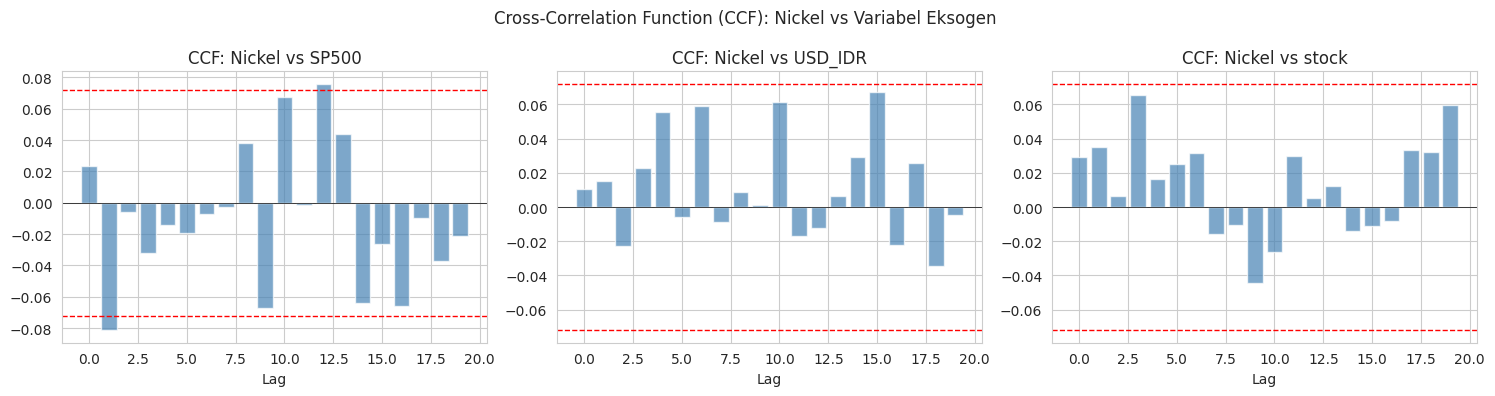

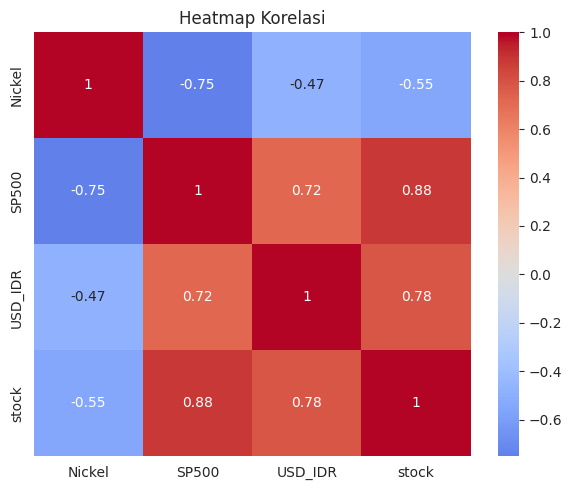

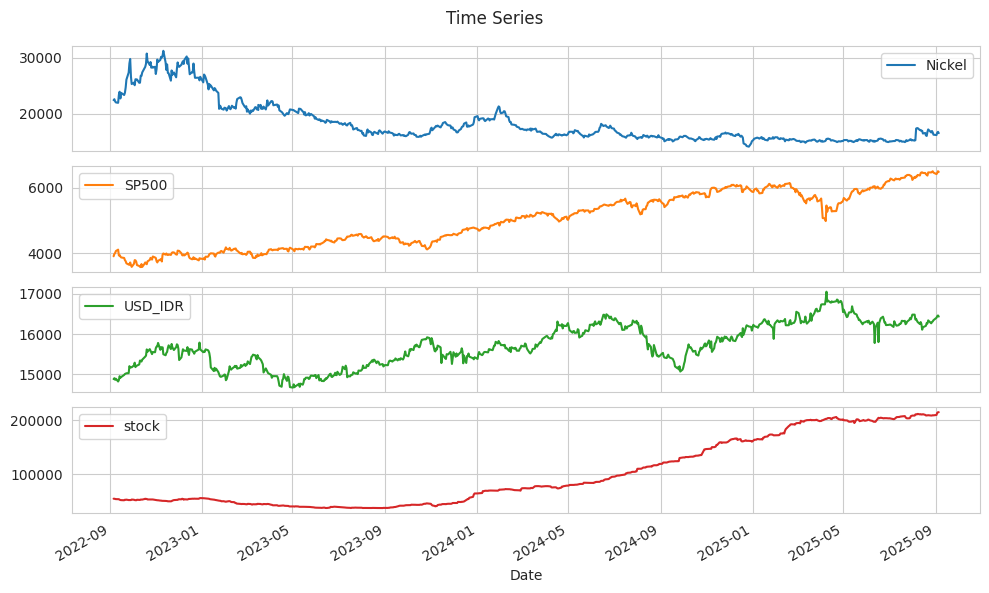


=== UJI NORMALITAS ===
  Nickel: Shapiro p=0.0000 (Tidak Normal) | JB p=0.0000 (Tidak Normal)
  SP500: Shapiro p=0.0000 (Tidak Normal) | JB p=0.0000 (Tidak Normal)
  USD_IDR: Shapiro p=0.0000 (Tidak Normal) | JB p=0.0000 (Tidak Normal)
  stock: Shapiro p=0.0000 (Tidak Normal) | JB p=0.0000 (Tidak Normal)


In [ ]:
# 1. DATA LOADING & EDA
url = "https://drive.google.com/uc?id=1DKVE4kuVMIBzp1uJ8i5Phl_aOOxNhKhw"
gdown.download(url, "data.csv", quiet=False)

df = pd.read_csv("data.csv")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.set_index('Date').sort_index()[["Nickel", "SP500", "USD_IDR", "stock"]]
df = df.drop(df.loc["2020-01-05":"2022-09-05"].index)
print(f"Rentang tanggal: {df.index.min().date()} → {df.index.max().date()} | {len(df)} baris")

print("\nMissing values:"); print(df.isna().sum())
print("\nStatistik deskriptif:"); print(df.describe())
print("\nMatriks korelasi:"); print(df.corr())

# VIF
X_vif = df.drop(columns=['Nickel']).assign(const=1)
vif_df = pd.DataFrame({
    "Variabel": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print("\nVariance Inflation Factor (VIF):"); print(vif_df)

# CCF: Cross-Correlation Function (Seleksi Variabel Eksogen)
print("\n=== CCF: KORELASI SILANG NICKEL vs VARIABEL EKSOGEN ===")
y_diff_eda = df["Nickel"].diff().dropna()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(["SP500", "USD_IDR", "stock"]):
    x_diff = df[col].diff().dropna()
    common_idx = y_diff_eda.index.intersection(x_diff.index)
    ccf_vals = compute_ccf(y_diff_eda.loc[common_idx], x_diff.loc[common_idx], nlags=20, adjusted=False)
    ci = 1.96 / np.sqrt(len(common_idx))
    axes[i].bar(range(len(ccf_vals)), ccf_vals, color='steelblue', alpha=0.7)
    axes[i].axhline(ci, color='red', linestyle='--', linewidth=1, label='Batas 95%')
    axes[i].axhline(-ci, color='red', linestyle='--', linewidth=1)
    axes[i].axhline(0, color='black', linewidth=0.5)
    axes[i].set_title(f"CCF: Nickel vs {col}"); axes[i].set_xlabel("Lag")
    peak_lag = int(np.argmax(np.abs(ccf_vals)))
    print(f"  Nickel vs {col}: CCF lag={peak_lag}, nilai={ccf_vals[peak_lag]:.4f} "
          f"(signifikan={'Ya' if abs(ccf_vals[peak_lag]) > ci else 'Tidak'})")
plt.suptitle("Cross-Correlation Function (CCF): Nickel vs Variabel Eksogen")
plt.tight_layout(); plt.show()

# Visualisasi korelasi
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Heatmap Korelasi"); plt.tight_layout(); plt.show()

# Time series plot
df.plot(subplots=True, figsize=(10, 6), title="Time Series")
plt.tight_layout(); plt.show()

# Uji normalitas (Shapiro-Wilk + Jarque-Bera)
print("\n=== UJI NORMALITAS ===")
for col in df.columns:
    d = df[col].dropna()
    sw_s, sw_p = shapiro(d); jb_s, jb_p = jarque_bera(d)
    print(f"  {col}: Shapiro p={sw_p:.4f} ({'Normal' if sw_p>0.05 else 'Tidak Normal'}) | "
          f"JB p={jb_p:.4f} ({'Normal' if jb_p>0.05 else 'Tidak Normal'})")


=== ADF TEST ===
ADF Nickel (Level): stat=-2.2516, p=0.1881 => Tidak Stasioner
ADF Nickel (1st Diff): stat=-7.1560, p=0.0000 => Stasioner
Durbin-Watson: 2.1322 => Tidak ada autokorelasi


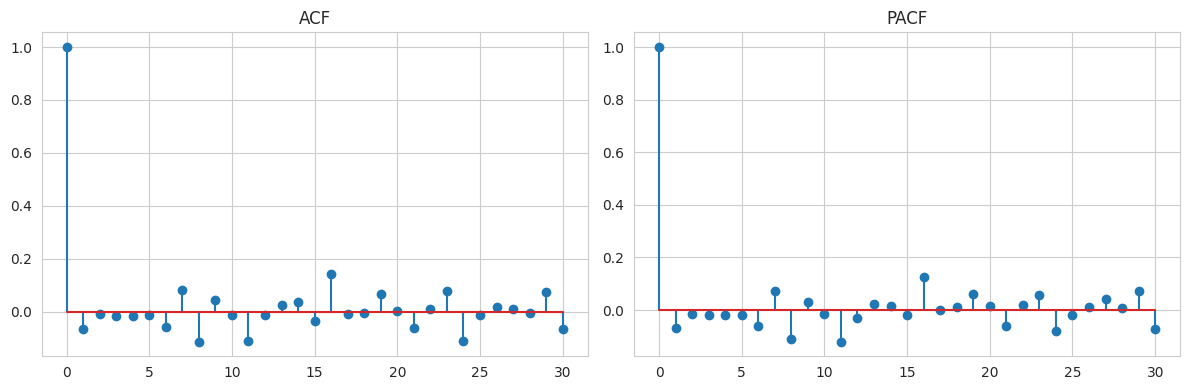


Outlier diperbaiki: 4
ADF Nickel (2nd Diff, setelah neighbor median): stat=-10.5748, p=0.0000 => Stasioner


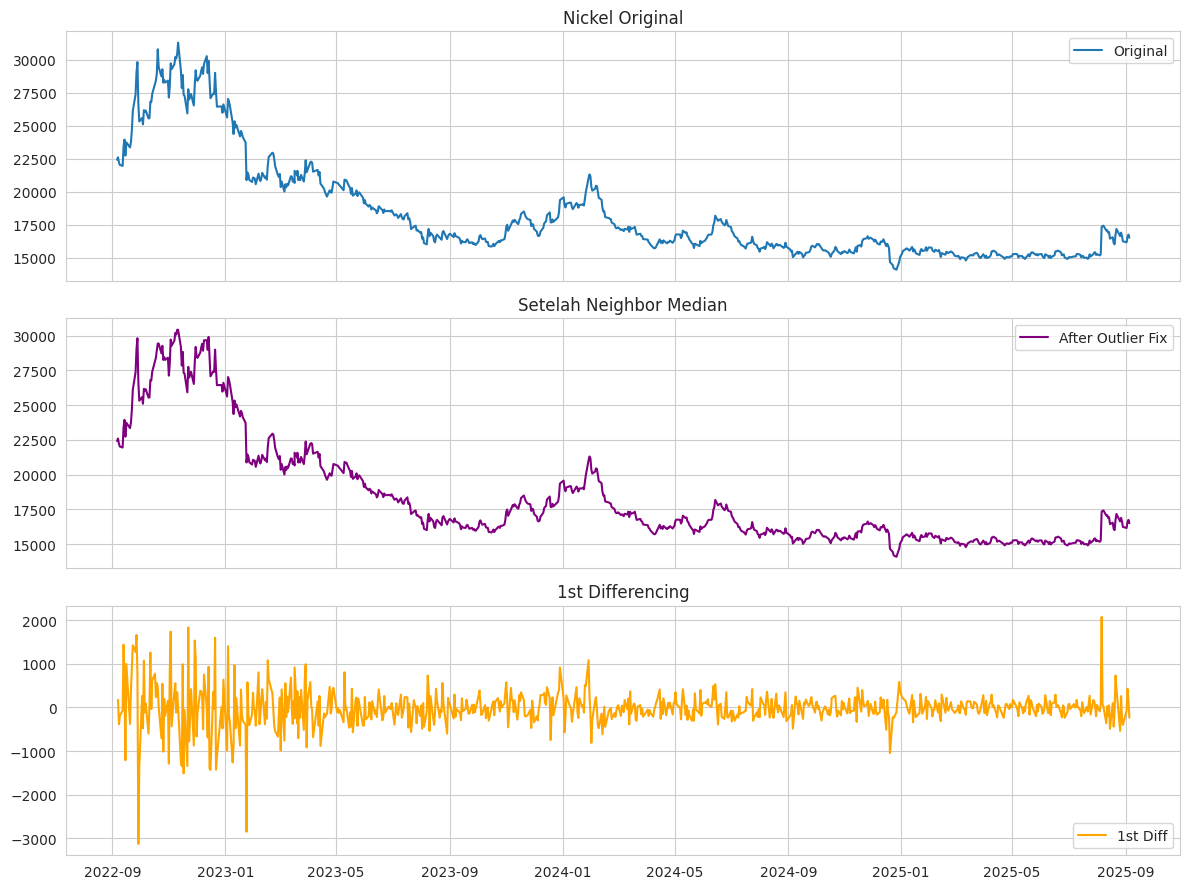

In [ ]:
# 2. STATIONARITY (ADF) + ACF/PACF
y = df["Nickel"]

def adf_test(s, label):
    r = adfuller(s.dropna())
    status = 'Stasioner' if r[1] <= 0.05 else 'Tidak Stasioner'
    print(f"ADF {label}: stat={r[0]:.4f}, p={r[1]:.4f} => {status}")

print("\n=== ADF TEST ===")
adf_test(y, "Nickel (Level)")
y_diff = y.diff().dropna()
adf_test(y_diff, "Nickel (1st Diff)")

dw = durbin_watson(y_diff)
print(f"Durbin-Watson: {dw:.4f} => "
      f"{'Autokorelasi positif' if dw<1.5 else 'Autokorelasi negatif' if dw>2.5 else 'Tidak ada autokorelasi'}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].stem(range(31), acf(y_diff, nlags=30)); axes[0].set_title("ACF")
axes[1].stem(range(31), pacf(y_diff, nlags=30)); axes[1].set_title("PACF")
plt.tight_layout(); plt.show()

# Outlier detection (Neighbor Median)
y_clean = y.copy()
rolling_median = y_clean.rolling(window=3, center=True).median()
threshold = y_clean.quantile(0.995)
mask_outlier = y_clean > threshold
y_clean[mask_outlier] = rolling_median[mask_outlier]
y_diff1 = y_clean.diff().dropna()
y_diff2 = y_diff1.diff().dropna()
print(f"\nOutlier diperbaiki: {mask_outlier.sum()}")
adf_test(y_diff2, "Nickel (2nd Diff, setelah neighbor median)")

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(y, label="Original"); axes[0].set_title("Nickel Original"); axes[0].legend()
axes[1].plot(y_clean, label="After Outlier Fix", color="purple"); axes[1].set_title("Setelah Neighbor Median"); axes[1].legend()
axes[2].plot(y_diff1, label="1st Diff", color="orange"); axes[2].set_title("1st Differencing"); axes[2].legend()
plt.tight_layout(); plt.show()

In [ ]:
# 3. BOX-COX TRANSFORMATION & UJI ASUMSI
df = df.dropna()

for col in ["Nickel", "SP500", "USD_IDR", "stock"]:
    df[f"bc_{col}"], _, _ = boxcox_transform(df[col])
    df[f"bc_diff_{col}"] = df[f"bc_{col}"].diff()
df_diff = df.dropna()

bc_vars      = ["bc_Nickel", "bc_SP500", "bc_USD_IDR", "bc_stock"]
bc_diff_vars = ["bc_diff_Nickel", "bc_diff_SP500", "bc_diff_USD_IDR", "bc_diff_stock"]

def run_assumption_tests(data_df, vars_list, title):
    print(f"\n=== {title} ===")
    n = len(data_df); mid = n // 2
    for var in vars_list:
        d = data_df[var].dropna().values
        s = d[:5000] if len(d) > 5000 else d
        _, p_sw = shapiro(s)
        _, p_dp = normaltest(d) if len(d) > 8 else (np.nan, np.nan)
        dw_s    = durbin_watson(d) if np.nanstd(d) > 1e-10 else np.nan
        g1, g2  = data_df[var].iloc[:mid].values, data_df[var].iloc[mid:].values
        lev_s, p_lev = levene(g1, g2)
        p_dp_str = f"{p_dp:.4f}" if not np.isnan(p_dp) else "nan"
        dw_str   = f"{dw_s:.4f}"  if not np.isnan(dw_s)  else "nan"
        print(f"  {var}: Shapiro p={p_sw:.4f} | D'Agostino p={p_dp_str} | "
              f"DW={dw_str} | Levene p={p_lev:.4f}")

run_assumption_tests(df, bc_vars, "NORMALITAS SETELAH BOX-COX")
run_assumption_tests(df_diff, bc_diff_vars, "NORMALITAS SETELAH BOX-COX + DIFFERENCING")


=== NORMALITAS SETELAH BOX-COX ===
  bc_Nickel: Shapiro p=1.0000 | D'Agostino p=nan | DW=nan | Levene p=nan
  bc_SP500: Shapiro p=0.0000 | D'Agostino p=0.0000 | DW=0.0000 | Levene p=0.1284
  bc_USD_IDR: Shapiro p=0.0000 | D'Agostino p=0.0000 | DW=0.0000 | Levene p=0.8617
  bc_stock: Shapiro p=0.0000 | D'Agostino p=0.0000 | DW=0.0000 | Levene p=0.0000

=== NORMALITAS SETELAH BOX-COX + DIFFERENCING ===
  bc_diff_Nickel: Shapiro p=1.0000 | D'Agostino p=nan | DW=nan | Levene p=nan
  bc_diff_SP500: Shapiro p=0.0000 | D'Agostino p=0.0000 | DW=2.0681 | Levene p=0.7251
  bc_diff_USD_IDR: Shapiro p=0.0000 | D'Agostino p=0.0000 | DW=2.3952 | Levene p=0.3704
  bc_diff_stock: Shapiro p=0.0000 | D'Agostino p=0.0000 | DW=1.4660 | Levene p=0.0000


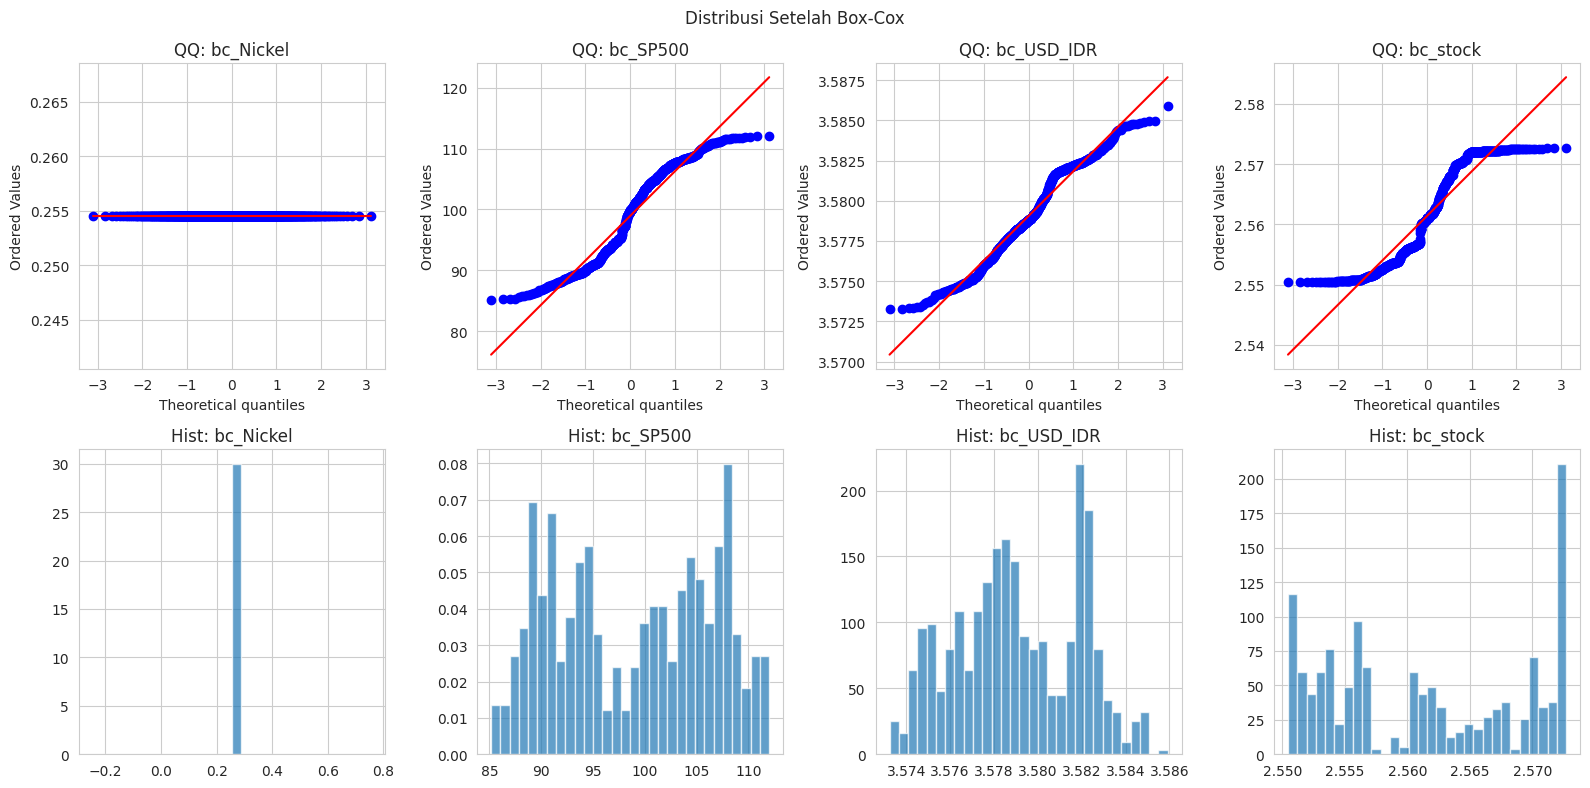

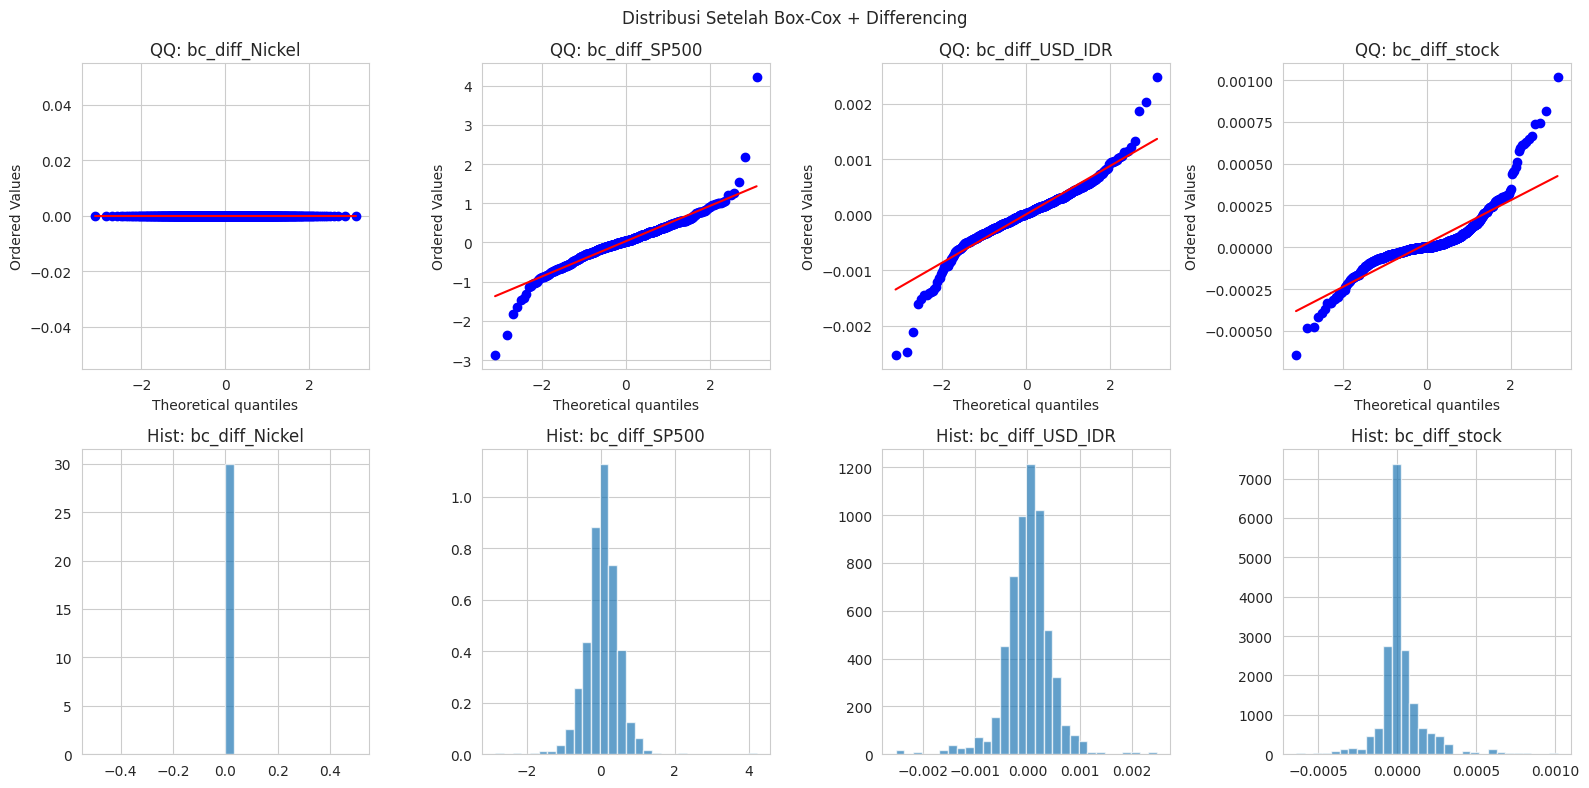

                               SARIMAX Results                                
Dep. Variable:                 Nickel   No. Observations:                  592
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -4476.988
Date:                Mon, 11 May 2026   AIC                           8959.975
Time:                        04:22:19   BIC                           8973.115
Sample:                             0   HQIC                          8965.094
                                - 592                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
d_SP500       65.1671     27.360      2.382      0.017      11.542     118.792
ar.L1         -0.0704      0.022     -3.224      0.001      -0.113      -0.028
sigma2      2.283e+05   6838.224     33.384      0.0

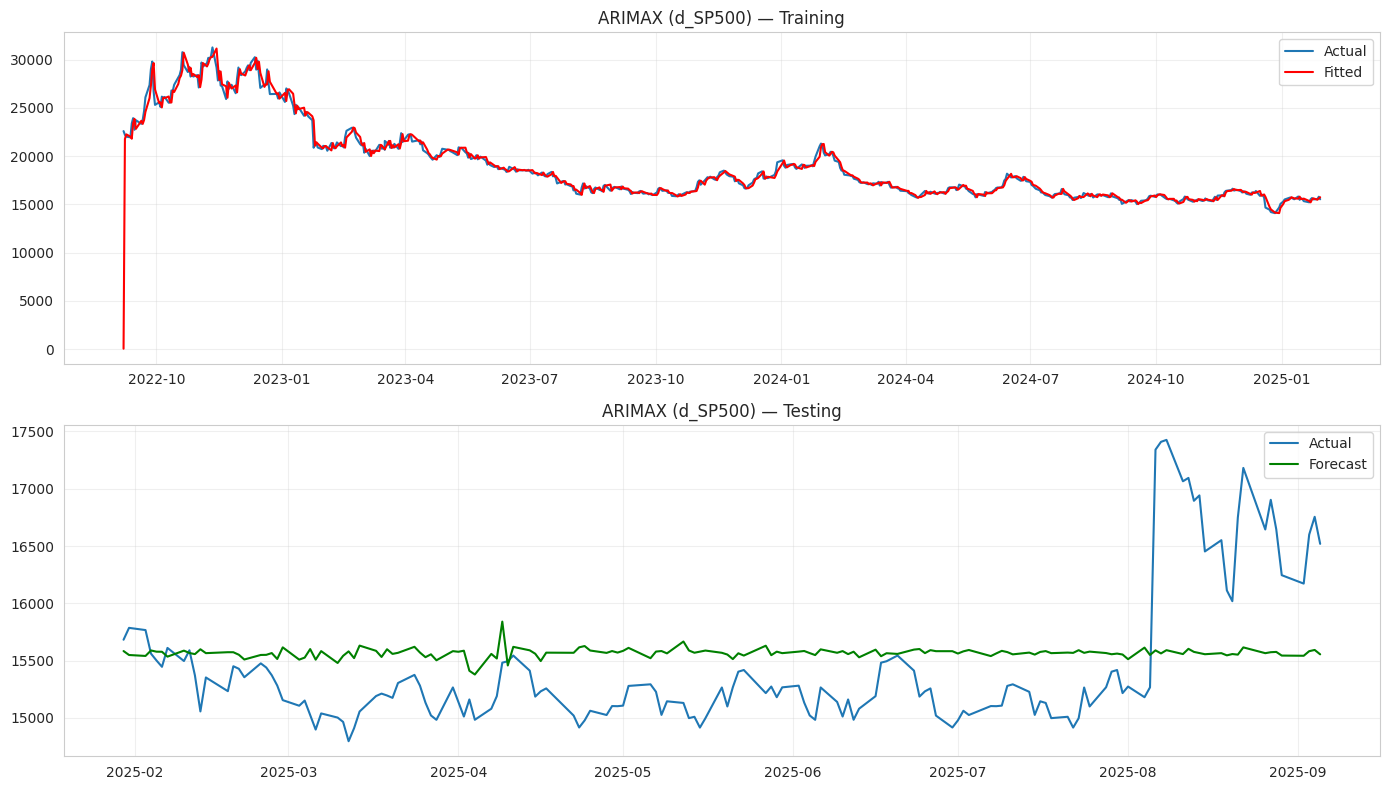

In [ ]:
# QQ-plot + Histogram
for data_df, vars_list, title in [(df, bc_vars, "Setelah Box-Cox"),
                                   (df_diff, bc_diff_vars, "Setelah Box-Cox + Differencing")]:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, var in enumerate(vars_list):
        d = data_df[var].dropna().values
        probplot(d, dist="norm", plot=axes[0, i]); axes[0, i].set_title(f"QQ: {var}")
        axes[1, i].hist(d, bins=30, density=True, alpha=0.7); axes[1, i].set_title(f"Hist: {var}")
    plt.suptitle(f"Distribusi {title}"); plt.tight_layout(); plt.show()

# 4. ARIMAX — Variabel Eksogen: d_SP500 | Order: (1,1,0) | Split 80/20
df_ax = pd.read_csv("data.csv")
df_ax['Date'] = pd.to_datetime(df_ax['Date'], errors='coerce')
df_ax = df_ax.set_index('Date').sort_index()[["Nickel", "SP500", "USD_IDR", "stock"]]
df_ax = df_ax.drop(df_ax.loc["2020-01-05":"2022-09-05"].index).dropna()

df_ax["bc_SP500"], _, _ = boxcox_transform(df_ax["SP500"])
df_ax["d_SP500"] = pd.Series(df_ax["bc_SP500"]).diff()
df_ax = df_ax.dropna()

n_ax = int(len(df_ax) * 0.8)
tr_ax, te_ax   = df_ax.iloc[:n_ax], df_ax.iloc[n_ax:]
y_tr_ax, y_te_ax = tr_ax["Nickel"], te_ax["Nickel"]
X_tr_ax, X_te_ax = tr_ax[["d_SP500"]], te_ax[["d_SP500"]]

model_ax = SARIMAX(y_tr_ax, exog=X_tr_ax, order=(1, 1, 0),
                   enforce_stationarity=False, enforce_invertibility=False)
res_ax = model_ax.fit(disp=False)
print(res_ax.summary())

fcast_ax   = res_ax.predict(start=len(y_tr_ax), end=len(df_ax)-1, exog=X_te_ax)
fitted_ax  = res_ax.fittedvalues

print("\n=== EVALUASI ARIMAX (d_SP500) ===")
calc_metrics(y_tr_ax, fitted_ax, "ARIMAX TRAIN")
calc_metrics(y_te_ax, fcast_ax,  "ARIMAX TEST")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(y_tr_ax.index, y_tr_ax, label="Actual"); axes[0].plot(fitted_ax.index, fitted_ax, label="Fitted", color="red")
axes[0].set_title("ARIMAX (d_SP500) — Training"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(y_te_ax.index, y_te_ax, label="Actual"); axes[1].plot(y_te_ax.index, fcast_ax, label="Forecast", color="green")
axes[1].set_title("ARIMAX (d_SP500) — Testing"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

1. UJI AUTOKORELASI RESIDUAL (Ljung-Box)
   H0: Tidak ada autokorelasi pada residual
   H1: Terdapat autokorelasi signifikan
      lb_stat  lb_pvalue
10   6.617898   0.760958
20  21.067576   0.393165
30  25.767547   0.686942
  Lag 10: p-value = 0.7610 => Gagal tolak H0 (tidak ada autokorelasi)
  Lag 20: p-value = 0.3932 => Gagal tolak H0 (tidak ada autokorelasi)
  Lag 30: p-value = 0.6869 => Gagal tolak H0 (tidak ada autokorelasi)

2. UJI NORMALITAS RESIDUAL (Jarque-Bera)
   H0: Residual berdistribusi normal
   H1: Residual tidak berdistribusi normal
  JB statistik = 3332676.0693, p-value = 0.0000
  Kesimpulan  : Tolak H0 (residual tidak normal)

3. UJI HOMOSKEDASTISITAS RESIDUAL (Breusch-Pagan)
   H0: Residual bersifat homoskedastik (ragam konstan)
   H1: Residual bersifat heteroskedastik
  LM statistik  = 18.5583, p-value = 0.0000
  F  statistik  = 19.0942, p-value = 0.0000
  Kesimpulan   : Tolak H0 (heteroskedastik)

4. UJI LINEARITAS (Ramsey RESET)
   H0: Spesifikasi model linier s

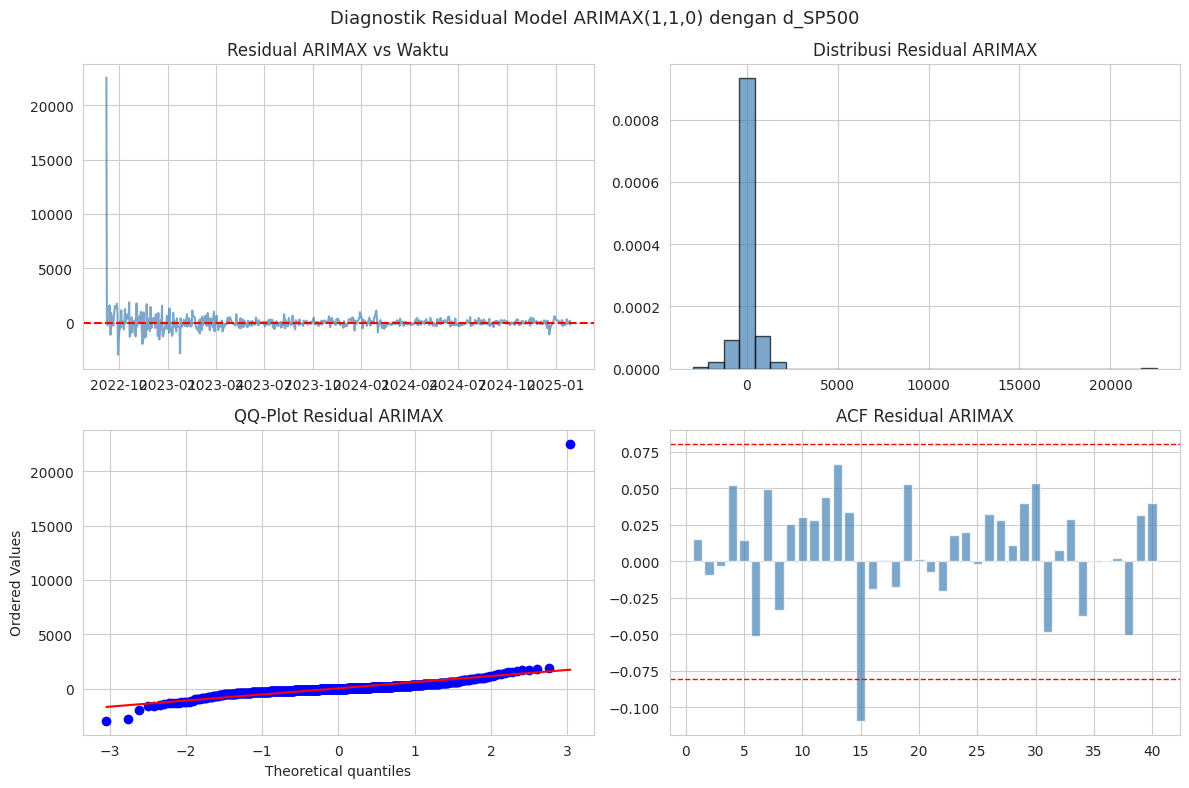


=== RINGKASAN DIAGNOSTIK ARIMAX ===
Uji                                    Statistik    p-value Kesimpulan
---------------------------------------------------------------------------
Ljung-Box (lag=10)                        6.6179     0.7610 OK (tidak ada autokorelasi)
Jarque-Bera (normalitas)            3332676.0693     0.0000 Tidak normal
Breusch-Pagan (homoskedastisitas)        18.5583     0.0000 Heteroskedastik
Ramsey RESET (linearitas)              1082.0064     0.0000 Nonlinier terdeteksi


In [ ]:
# ============================================================
# ARIMAX DIAGNOSTIC TESTS (Revisi Dosen 2)
# Uji: Ljung-Box | Jarque-Bera | Breusch-Pagan | RESET | BDS
# ============================================================

resid_ax = res_ax.resid.dropna()
fitted_ax_vals = res_ax.fittedvalues.iloc[-len(resid_ax):]
n_r = len(resid_ax)

# ---- 1. Ljung-Box: Uji Autokorelasi Residual ----
print("=" * 60)
print("1. UJI AUTOKORELASI RESIDUAL (Ljung-Box)")
print("   H0: Tidak ada autokorelasi pada residual")
print("   H1: Terdapat autokorelasi signifikan")
print("=" * 60)
lb_res = acorr_ljungbox(resid_ax, lags=[10, 20, 30], return_df=True)
print(lb_res.to_string())
for lag in [10, 20, 30]:
    p = lb_res.loc[lag, 'lb_pvalue']
    kes = "Gagal tolak H0 (tidak ada autokorelasi)" if p > 0.05 else "Tolak H0 (ada autokorelasi)"
    print(f"  Lag {lag:2d}: p-value = {p:.4f} => {kes}")

# ---- 2. Jarque-Bera: Uji Normalitas Residual ----
print("\n" + "=" * 60)
print("2. UJI NORMALITAS RESIDUAL (Jarque-Bera)")
print("   H0: Residual berdistribusi normal")
print("   H1: Residual tidak berdistribusi normal")
print("=" * 60)
from scipy.stats import jarque_bera as jb_fn
jb_s, jb_p = jb_fn(resid_ax)
print(f"  JB statistik = {jb_s:.4f}, p-value = {jb_p:.4f}")
kes_jb = "Gagal tolak H0 (residual normal)" if jb_p > 0.05 else "Tolak H0 (residual tidak normal)"
print(f"  Kesimpulan  : {kes_jb}")

# ---- 3. Breusch-Pagan: Uji Homoskedastisitas ----
print("\n" + "=" * 60)
print("3. UJI HOMOSKEDASTISITAS RESIDUAL (Breusch-Pagan)")
print("   H0: Residual bersifat homoskedastik (ragam konstan)")
print("   H1: Residual bersifat heteroskedastik")
print("=" * 60)
exog_bp = add_constant(fitted_ax_vals.values)
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(resid_ax.values, exog_bp)
print(f"  LM statistik  = {bp_lm:.4f}, p-value = {bp_p:.4f}")
print(f"  F  statistik  = {bp_f:.4f}, p-value = {bp_fp:.4f}")
kes_bp = "Gagal tolak H0 (homoskedastik)" if bp_p > 0.05 else "Tolak H0 (heteroskedastik)"
print(f"  Kesimpulan   : {kes_bp}")

# ---- 4. Ramsey RESET: Uji Linearitas ----
print("\n" + "=" * 60)
print("4. UJI LINEARITAS (Ramsey RESET)")
print("   H0: Spesifikasi model linier sudah memadai")
print("   H1: Terdapat struktur nonlinier yang tidak tertangkap")
print("=" * 60)
fv = fitted_ax_vals.values.reshape(-1, 1)
X_r  = np.column_stack([np.ones(n_r), fv])          # restricted
X_u  = np.column_stack([np.ones(n_r), fv, fv**2, fv**3])  # unrestricted
ols_r = OLS(resid_ax.values, X_r).fit()
ols_u = OLS(resid_ax.values, X_u).fit()
q_reset = 2   # dua restriksi: fv^2 dan fv^3
k_reset = 4   # total parameter model unrestricted
rss_r_reset = float(np.sum(ols_r.resid**2))
rss_u_reset = float(np.sum(ols_u.resid**2))
F_reset = ((rss_r_reset - rss_u_reset) / q_reset) / (rss_u_reset / (n_r - k_reset))
p_reset = float(1 - f_dist.cdf(F_reset, q_reset, n_r - k_reset))
print(f"  RESET F-statistik = {F_reset:.4f}, p-value = {p_reset:.4f}")
kes_reset = "Gagal tolak H0 (spesifikasi linier memadai)" if p_reset > 0.05 else "Tolak H0 (ada struktur nonlinier)"
print(f"  Kesimpulan       : {kes_reset}")

# ---- 5. BDS: Uji Nonlinearitas Residual ----
print("\n" + "=" * 60)
print("5. UJI NONLINEARITAS RESIDUAL (BDS)")
print("   H0: Residual bersifat iid (tidak ada dependensi nonlinier)")
print("   H1: Terdapat struktur dependensi nonlinier pada residual")
print("=" * 60)
try:
    bds_stat, bds_pval = bds(resid_ax.values, max_dim=4)
    for dim_idx, (s, p) in enumerate(zip(bds_stat, bds_pval), start=2):
        kes_bds = "Gagal tolak H0 (iid)" if p > 0.05 else "Tolak H0 (ada dependensi nonlinier)"
        print(f"  Dimensi m={dim_idx}: BDS={s:.4f}, p-value={p:.4f} => {kes_bds}")
except Exception as e:
    print(f"  BDS test error: {e}")

# ---- Visualisasi Diagnostik Residual ----
print("\n")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].plot(resid_ax.index, resid_ax.values, alpha=0.7, color='steelblue')
axes[0,0].axhline(0, color='red', linestyle='--'); axes[0,0].set_title("Residual ARIMAX vs Waktu")
axes[0,1].hist(resid_ax.values, bins=30, density=True, edgecolor='black', alpha=0.7, color='steelblue')
axes[0,1].set_title("Distribusi Residual ARIMAX")
probplot(resid_ax.values, dist="norm", plot=axes[1,0]); axes[1,0].set_title("QQ-Plot Residual ARIMAX")
lags_acf = min(40, n_r // 2)
acf_vals = acf(resid_ax, nlags=lags_acf)
ci_acf = 1.96 / np.sqrt(n_r)
axes[1,1].bar(range(1, lags_acf+1), acf_vals[1:], color='steelblue', alpha=0.7)
axes[1,1].axhline(ci_acf, color='red', linestyle='--', linewidth=1)
axes[1,1].axhline(-ci_acf, color='red', linestyle='--', linewidth=1)
axes[1,1].set_title("ACF Residual ARIMAX")
plt.suptitle("Diagnostik Residual Model ARIMAX(1,1,0) dengan d_SP500", fontsize=13)
plt.tight_layout(); plt.show()

print("\n=== RINGKASAN DIAGNOSTIK ARIMAX ===")
print(f"{'Uji':<35} {'Statistik':>12} {'p-value':>10} {'Kesimpulan'}")
print("-" * 75)
print(f"{'Ljung-Box (lag=10)':<35} {lb_res.loc[10,'lb_stat']:>12.4f} {lb_res.loc[10,'lb_pvalue']:>10.4f} {'OK (tidak ada autokorelasi)' if lb_res.loc[10,'lb_pvalue']>0.05 else 'Autokorelasi terdeteksi'}")
print(f"{'Jarque-Bera (normalitas)':<35} {jb_s:>12.4f} {jb_p:>10.4f} {'OK (normal)' if jb_p>0.05 else 'Tidak normal'}")
print(f"{'Breusch-Pagan (homoskedastisitas)':<35} {bp_lm:>12.4f} {bp_p:>10.4f} {'OK (homoskedastik)' if bp_p>0.05 else 'Heteroskedastik'}")
print(f"{'Ramsey RESET (linearitas)':<35} {F_reset:>12.4f} {p_reset:>10.4f} {'OK (linier)' if p_reset>0.05 else 'Nonlinier terdeteksi'}")

Downloading...
From: https://drive.google.com/uc?id=1DKVE4kuVMIBzp1uJ8i5Phl_aOOxNhKhw
To: /content/data.csv
100%|██████████| 49.8k/49.8k [00:00<00:00, 16.7MB/s]


CNN — Data: 741 sampel


Model: "CNN_Nickel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         9,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,383 (67.90 KB)

 Trainable params: 17,383 (67.90 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 140ms/step - loss: 0.1030 - mae: 0.2044 - val_loss: 0.0034 - val_mae: 0.0512
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0282 - mae: 0.1257 - val_loss: 0.0090 - val_mae: 0.0892
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0176 - mae: 0.1000 - val_loss: 0.0027 - val_mae: 0.0441
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0186 - mae: 0.0930 - val_loss: 0.0014 - val_mae: 0.0298
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0148 - mae: 0.0816 - val_loss: 0.0012 - val_mae: 0.0271
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0124 - mae: 0.0752 - val_loss: 8.9267e-04 - val_mae: 0.0236
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0152 - mae: 0.0803 - val_loss: 8.5471e-04 - val_mae: 0.0232
Epoch 8/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0124 - mae: 0.0721 - val_loss: 9.3605e-04 - val_mae: 0.0244
Epoch 9/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step 

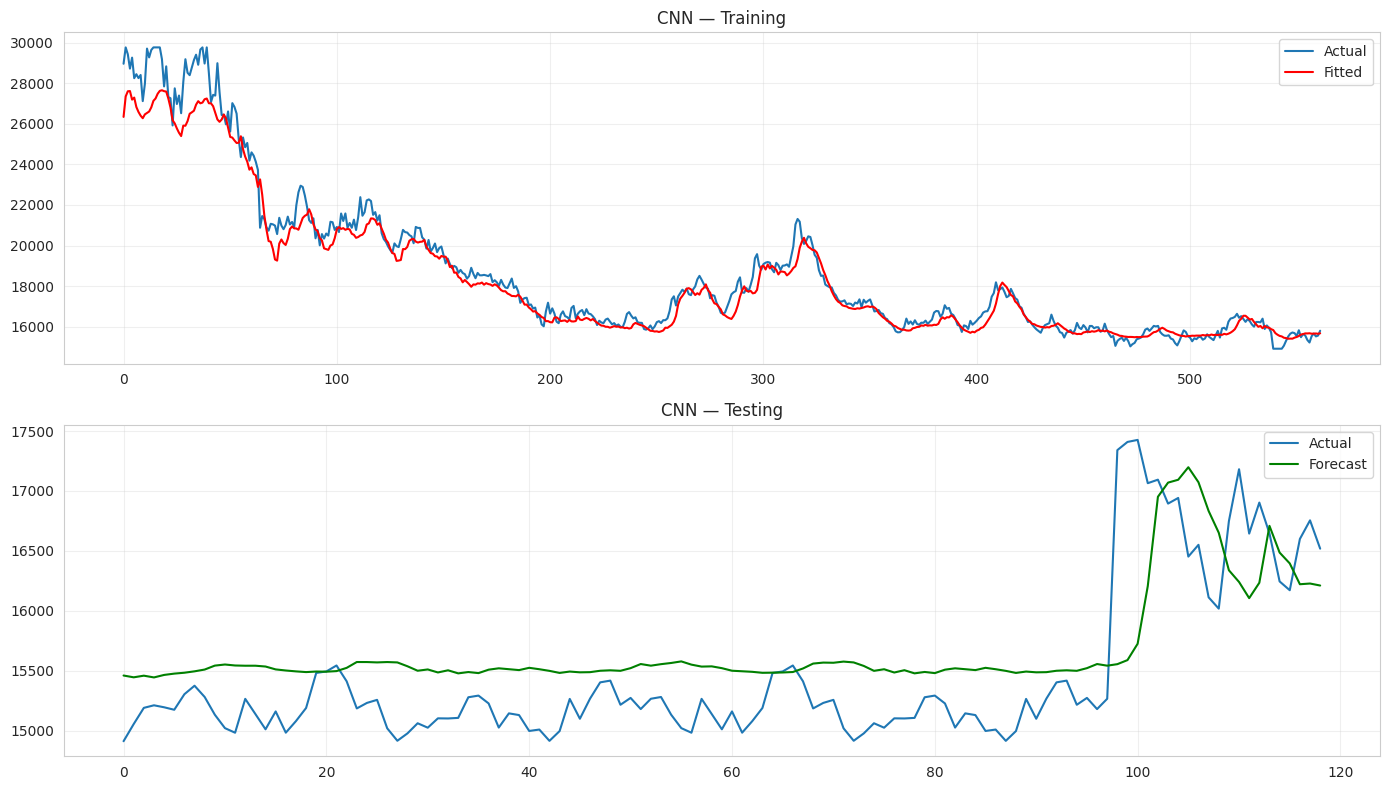

In [ ]:
# 5. CNN — Univariate, Window=30, 1-step ahead
try:
    gdown.download(url, "data.csv", quiet=False)
except Exception:
    pass

df = pd.read_csv("data.csv")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.set_index('Date').sort_index()[["Nickel", "SP500", "USD_IDR", "stock"]]
df = df.drop(df.loc["2020-01-05":"2022-09-05"].index).ffill().bfill()

# Winsorization outlier
for col in df.columns:
    df[col] = df[col].clip(df[col].quantile(0.01), df[col].quantile(0.99))
print(f"CNN — Data: {len(df)} sampel")

WINDOW, HORIZON = 30, 1
split_idx = int(len(df) * 0.8)
data_train_cnn, data_test_cnn = df.iloc[:split_idx], df.iloc[split_idx:]

scaler_cnn = MinMaxScaler()
tr_sc_cnn  = scaler_cnn.fit_transform(data_train_cnn[['Nickel']]).flatten()
te_sc_cnn  = scaler_cnn.transform(data_test_cnn[['Nickel']]).flatten()

X_tr_cnn, y_tr_cnn = build_sequences(tr_sc_cnn, WINDOW)
X_te_cnn, y_te_cnn = build_sequences(te_sc_cnn, WINDOW)

_W_CNN  = 'models/cnn.weights.h5'
_J_CNN  = 'models/cnn.json'
_P_CNN  = 'output/predictions_cnn.pkl'
FORCE_CNN = False

if all(os.path.exists(p) for p in [_W_CNN, _J_CNN, _P_CNN]) and not FORCE_CNN:
    with open(_J_CNN) as f:
        model_cnn = model_from_json(json.load(f))
    model_cnn.load_weights(_W_CNN)
    model_cnn.compile(loss='mse', optimizer=Adam(0.001, epsilon=1e-8), metrics=['mae'])
    with open(_P_CNN, 'rb') as f:
        _cnn = pickle.load(f)
    y_tr_cnn_orig, y_tr_cnn_fit = _cnn['y_train_actual'], _cnn['y_train_fitted']
    y_te_cnn_orig, y_pr_cnn     = _cnn['y_test_actual'],   _cnn['y_test_predicted']
    print("CNN: model dimuat dari file.")
else:
    model_cnn = Sequential([
        Conv1D(64, 3, activation='relu', input_shape=(WINDOW, 1)),
        MaxPooling1D(2),
        Conv1D(32, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(50, activation='relu'), Dropout(0.2),
        Dense(25, activation='relu'), Dropout(0.1),
        Dense(HORIZON)
    ], name='CNN_Nickel')
    model_cnn.compile(loss='mse', optimizer=Adam(0.001, epsilon=1e-8), metrics=['mae'])
    model_cnn.summary()
    cb_cnn = [
        EarlyStopping('val_loss', patience=20, restore_best_weights=True, verbose=1),
        ModelCheckpoint(_W_CNN, monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=0)
    ]
    model_cnn.fit(X_tr_cnn, y_tr_cnn, epochs=1000, batch_size=64,
                  validation_split=0.15, shuffle=False, callbacks=cb_cnn, verbose=1)
    with open(_J_CNN, 'w') as f:
        json.dump(model_cnn.to_json(), f)
    model_cnn.save_weights(_W_CNN)

    y_te_cnn_orig = scaler_cnn.inverse_transform(y_te_cnn.reshape(-1,1)).reshape(y_te_cnn.shape)
    y_pr_cnn      = scaler_cnn.inverse_transform(model_cnn.predict(X_te_cnn, verbose=0).reshape(-1,1)).reshape(y_te_cnn.shape)
    y_tr_cnn_orig = scaler_cnn.inverse_transform(y_tr_cnn.reshape(-1,1)).reshape(y_tr_cnn.shape)
    y_tr_cnn_fit  = scaler_cnn.inverse_transform(model_cnn.predict(X_tr_cnn, verbose=0).reshape(-1,1)).reshape(y_tr_cnn.shape)

    with open(_P_CNN, 'wb') as f:
        pickle.dump({'y_train_actual': y_tr_cnn_orig, 'y_train_fitted': y_tr_cnn_fit,
                     'y_test_actual':  y_te_cnn_orig, 'y_test_predicted': y_pr_cnn}, f)

# Simpan juga sebagai predictions_optimal.pkl (untuk bagian perbandingan)
with open('output/predictions_optimal.pkl', 'wb') as f:
    pickle.dump({'y_train_actual': y_tr_cnn_orig, 'y_train_fitted': y_tr_cnn_fit,
                 'y_test_actual':  y_te_cnn_orig, 'y_test_predicted': y_pr_cnn}, f)

print("\n=== EVALUASI CNN ===")
calc_metrics(y_tr_cnn_orig.flatten(), y_tr_cnn_fit.flatten(), "CNN TRAIN")
calc_metrics(y_te_cnn_orig.flatten(), y_pr_cnn.flatten(),     "CNN TEST")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(y_tr_cnn_orig.flatten(), label="Actual"); axes[0].plot(y_tr_cnn_fit.flatten(), label="Fitted", color="red")
axes[0].set_title("CNN — Training"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(y_te_cnn_orig.flatten(), label="Actual"); axes[1].plot(y_pr_cnn.flatten(), label="Forecast", color="green")
axes[1].set_title("CNN — Testing"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

LSTM — Data: 741 sampel


Model: "LSTM_Nickel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.8262 - mae: 0.6552 - val_loss: 0.2914 - val_mae: 0.5262
Epoch 2/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.2853 - mae: 0.3526 - val_loss: 0.0235 - val_mae: 0.1136
Epoch 3/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1798 - mae: 0.3146 - val_loss: 0.0267 - val_mae: 0.1245
Epoch 4/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.1182 - mae: 0.2364 - val_loss: 0.0363 - val_mae: 0.1551
Epoch 5/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0918 - mae: 0.2239 - val_loss: 0.0307 - val_mae: 0.1385
Epoch 6/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0957 - mae: 0.2198 - val_loss: 0.0293 - val_mae: 0.1339
Epoch 7/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0883 - mae: 0.2120 - val_loss: 0.0241 - val_mae: 0.1151
Epoch 8/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0925 - mae: 0.2140 - val_loss: 0.0336 - val_mae: 0.1471
Epoch 9/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/

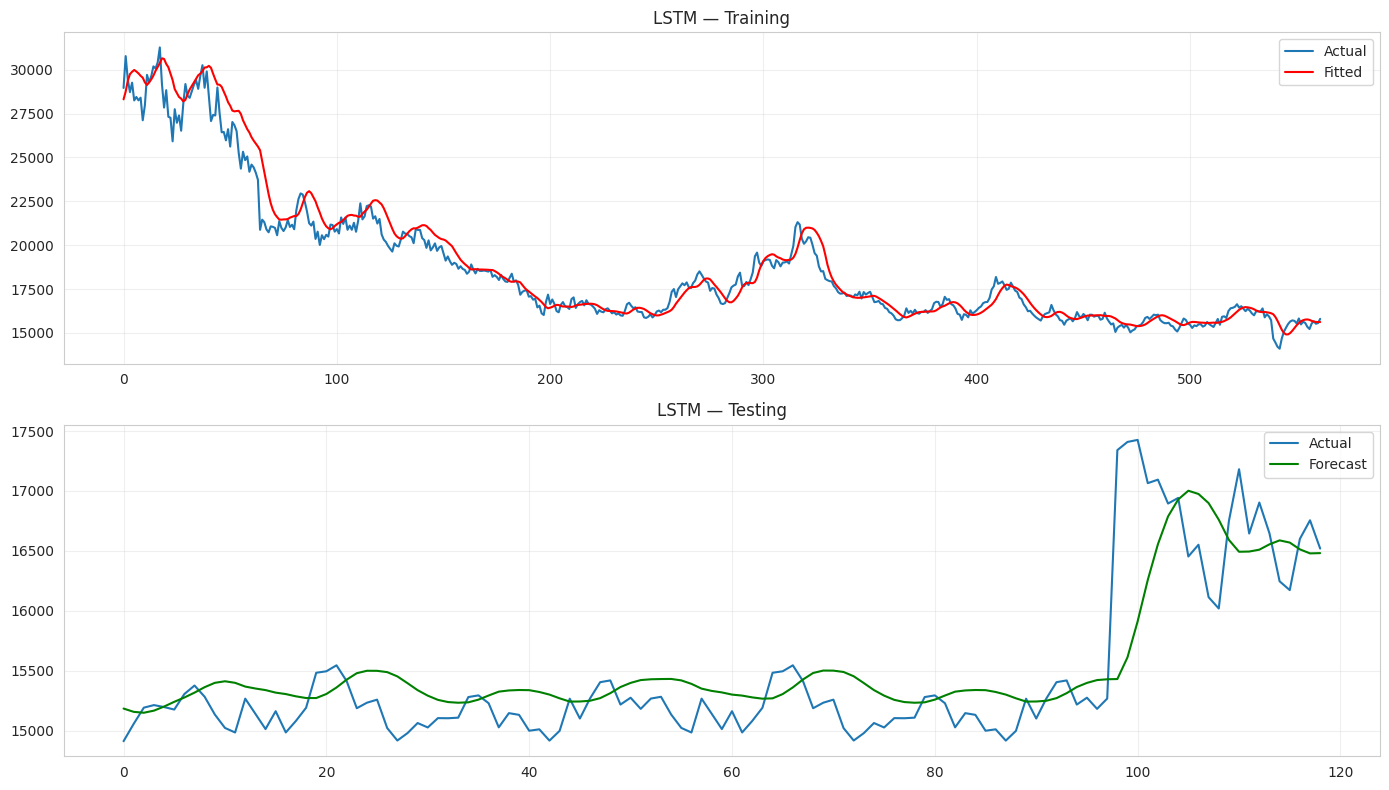

In [ ]:
# 6. LSTM — Univariate, Window=30, 1-step ahead
df = pd.read_csv("data.csv")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.set_index('Date').sort_index()[["Nickel", "SP500", "USD_IDR", "stock"]]
df = df.drop(df.loc["2020-01-05":"2022-09-05"].index).ffill().bfill()
print(f"LSTM — Data: {len(df)} sampel")

split_idx = int(len(df) * 0.8)
data_train_lstm, data_test_lstm = df.iloc[:split_idx], df.iloc[split_idx:]

scaler_lstm = StandardScaler()
tr_sc_lstm  = scaler_lstm.fit_transform(data_train_lstm[['Nickel']]).flatten()
te_sc_lstm  = scaler_lstm.transform(data_test_lstm[['Nickel']]).flatten()

X_tr_lstm, y_tr_lstm = build_sequences(tr_sc_lstm, WINDOW)
X_te_lstm, y_te_lstm = build_sequences(te_sc_lstm, WINDOW)

_W_LSTM = 'models/lstm.weights.h5'
_J_LSTM = 'models/lstm.json'
_P_LSTM = 'output/predictions_default.pkl'
FORCE_LSTM = False

if all(os.path.exists(p) for p in [_W_LSTM, _J_LSTM, _P_LSTM]) and not FORCE_LSTM:
    with open(_J_LSTM) as f:
        model_lstm = model_from_json(json.load(f))
    model_lstm.load_weights(_W_LSTM)
    model_lstm.compile(loss='mse', optimizer=Adam(0.001, epsilon=1e-8), metrics=['mae'])
    with open(_P_LSTM, 'rb') as f:
        _lstm = pickle.load(f)
    y_tr_lstm_orig, y_tr_lstm_fit = _lstm['y_train_actual'], _lstm['y_train_fitted']
    y_te_lstm_orig, y_pr_lstm     = _lstm['y_test_actual'],   _lstm['y_test_predicted']
    print("LSTM: model dimuat dari file.")
else:
    model_lstm = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)), Dropout(0.2),
        LSTM(32, return_sequences=False), Dropout(0.2),
        Dense(16, activation='relu'), Dropout(0.1),
        Dense(HORIZON)
    ], name='LSTM_Nickel')
    model_lstm.compile(loss='mse', optimizer=Adam(0.001, epsilon=1e-8), metrics=['mae'])
    model_lstm.summary()
    cb_lstm = [
        EarlyStopping('val_loss', patience=20, restore_best_weights=True, verbose=1),
        ModelCheckpoint(_W_LSTM, monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=0)
    ]
    model_lstm.fit(X_tr_lstm, y_tr_lstm, epochs=1000, batch_size=32,
                   validation_split=0.15, shuffle=False, callbacks=cb_lstm, verbose=1)
    with open(_J_LSTM, 'w') as f:
        json.dump(model_lstm.to_json(), f)
    model_lstm.save_weights(_W_LSTM)

    y_te_lstm_orig = scaler_lstm.inverse_transform(y_te_lstm.reshape(-1,1)).reshape(y_te_lstm.shape)
    y_pr_lstm      = scaler_lstm.inverse_transform(model_lstm.predict(X_te_lstm, verbose=0).reshape(-1,1)).reshape(y_te_lstm.shape)
    y_tr_lstm_orig = scaler_lstm.inverse_transform(y_tr_lstm.reshape(-1,1)).reshape(y_tr_lstm.shape)
    y_tr_lstm_fit  = scaler_lstm.inverse_transform(model_lstm.predict(X_tr_lstm, verbose=0).reshape(-1,1)).reshape(y_tr_lstm.shape)

    with open(_P_LSTM, 'wb') as f:
        pickle.dump({'y_train_actual': y_tr_lstm_orig, 'y_train_fitted': y_tr_lstm_fit,
                     'y_test_actual':  y_te_lstm_orig, 'y_test_predicted': y_pr_lstm}, f)

print("\n=== EVALUASI LSTM ===")
calc_metrics(y_tr_lstm_orig.flatten(), y_tr_lstm_fit.flatten(), "LSTM TRAIN")
calc_metrics(y_te_lstm_orig.flatten(), y_pr_lstm.flatten(),     "LSTM TEST")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(y_tr_lstm_orig.flatten(), label="Actual"); axes[0].plot(y_tr_lstm_fit.flatten(), label="Fitted", color="red")
axes[0].set_title("LSTM — Training"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(y_te_lstm_orig.flatten(), label="Actual"); axes[1].plot(y_pr_lstm.flatten(), label="Forecast", color="green")
axes[1].set_title("LSTM — Testing"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Downloading...
From: https://drive.google.com/uc?id=1DKVE4kuVMIBzp1uJ8i5Phl_aOOxNhKhw
To: /content/data.csv
100%|██████████| 49.8k/49.8k [00:00<00:00, 35.2MB/s]


Hybrid — Data: 741 sampel
Train: 592 | Test: 148


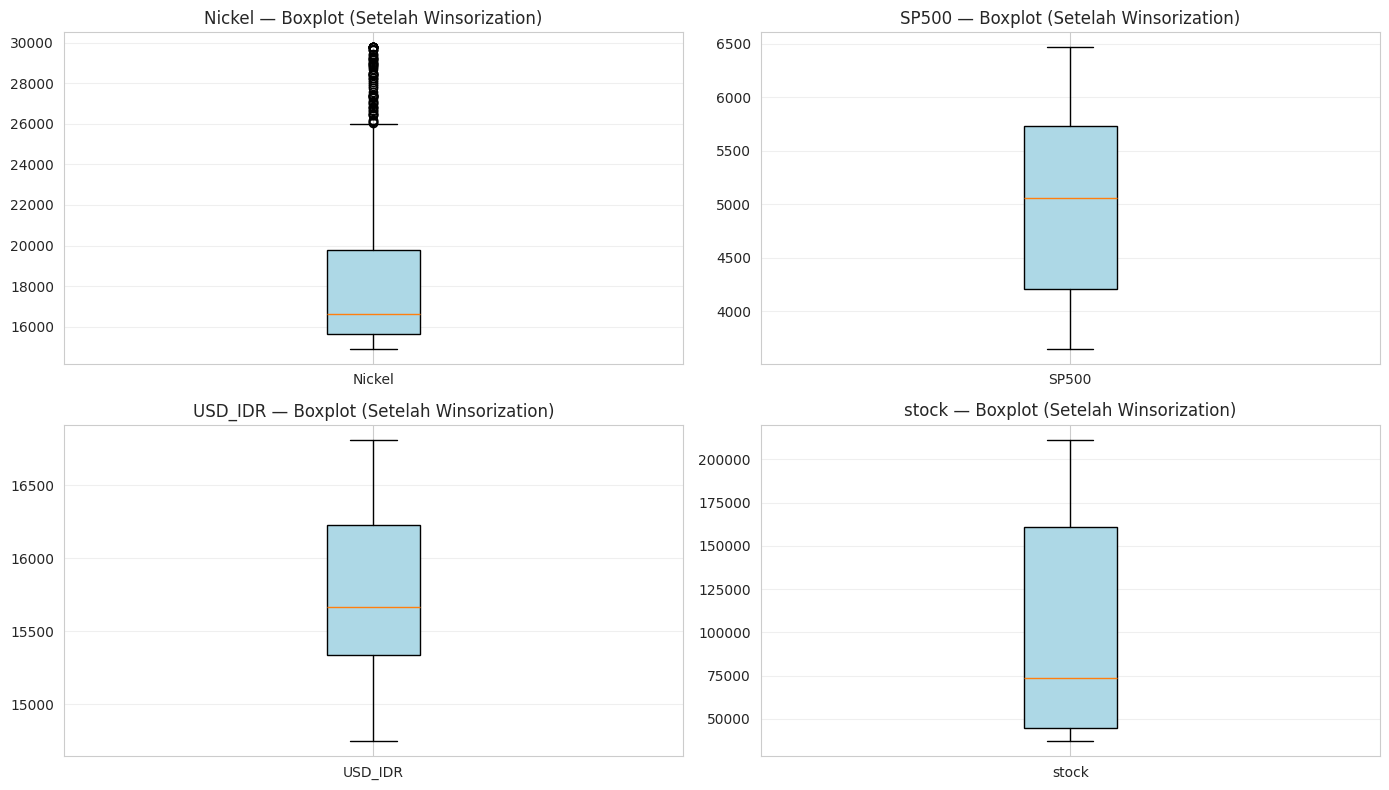

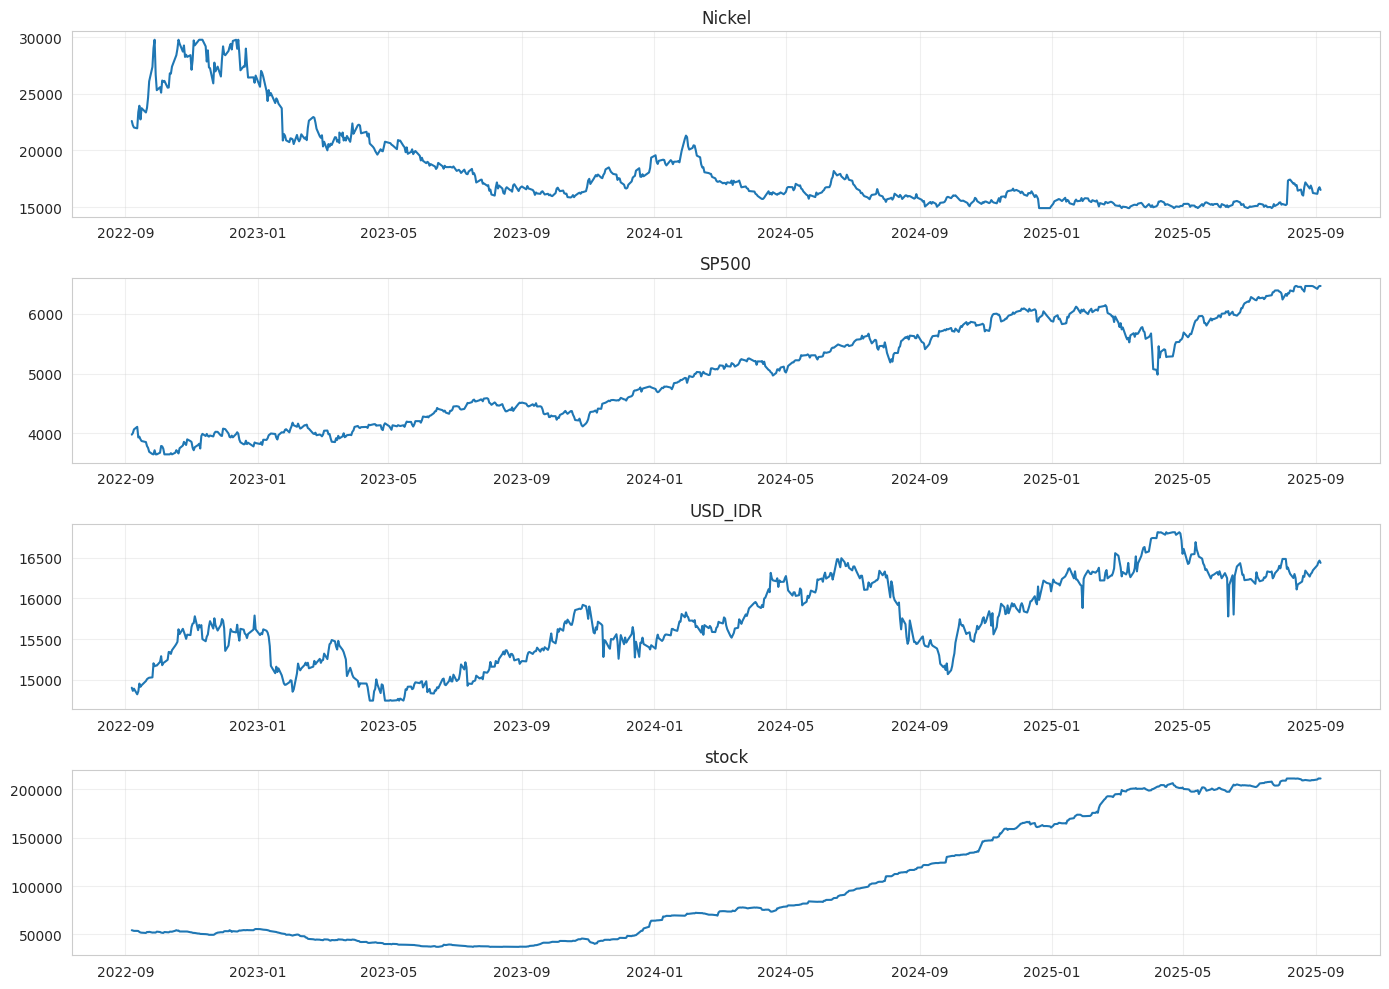

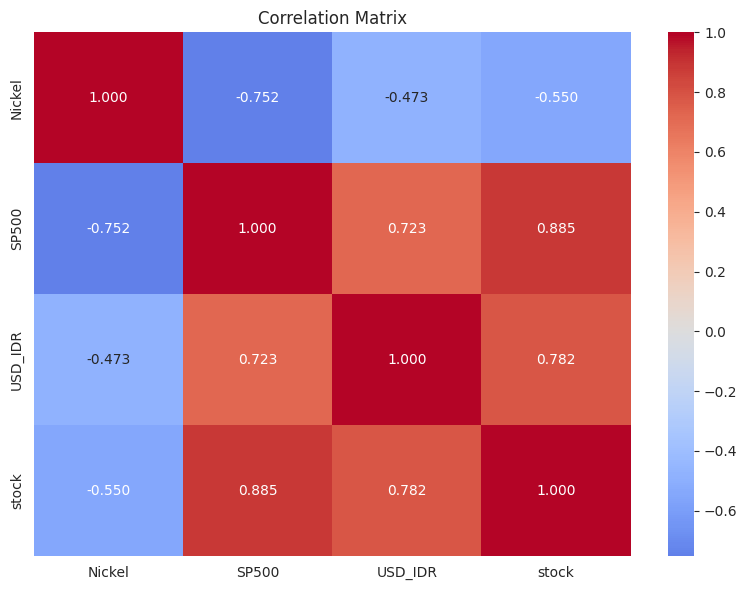


=== HYBRID — STEP 1: ARIMAX(1,1,0) ===
                               SARIMAX Results                                
Dep. Variable:                 Nickel   No. Observations:                  592
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -4448.190
Date:                Mon, 11 May 2026   AIC                           8902.380
Time:                        04:24:07   BIC                           8915.520
Sample:                             0   HQIC                          8907.499
                                - 592                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
d_SP500       64.4162     31.091      2.072      0.038       3.480     125.353
ar.L1         -0.0708      0.023     -3.135      0.002      -0.115      -0.027
sigma2      

Model: "CNN_LSTM_Residual"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 30, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 30, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 15, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,865 (206.50 KB)

 Trainable params: 52,865 (206.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0810 - mae: 0.2819 - val_loss: 0.0184 - val_mae: 0.1453 - learning_rate: 1.0000e-04
Epoch 2/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0805 - mae: 0.2796 - val_loss: 0.0184 - val_mae: 0.1452 - learning_rate: 1.0000e-04
Epoch 3/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0810 - mae: 0.2806 - val_loss: 0.0184 - val_mae: 0.1451 - learning_rate: 1.0000e-04
Epoch 4/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0820 - mae: 0.2827 - val_loss: 0.0184 - val_mae: 0.1451 - learning_rate: 1.0000e-04
Epoch 5/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0809 - mae: 0.2817 - val_loss: 0.0184 - val_mae: 0.1451 - learning_rate: 1.0000e-04
Epoch 6/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0813 - mae: 0.2812 - val_loss: 0.0183 - val_mae: 0.1451 - learning_rate: 1.0000e-04
Epoch 7/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0807 - mae: 0.2802 - val_loss: 0.0183 - val_mae: 0.145

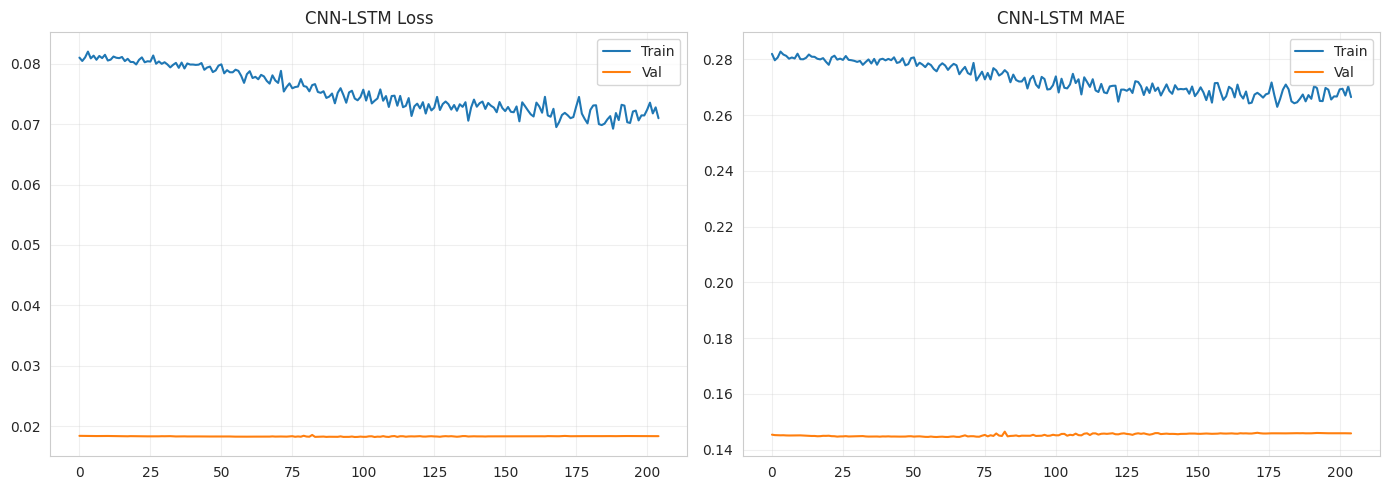

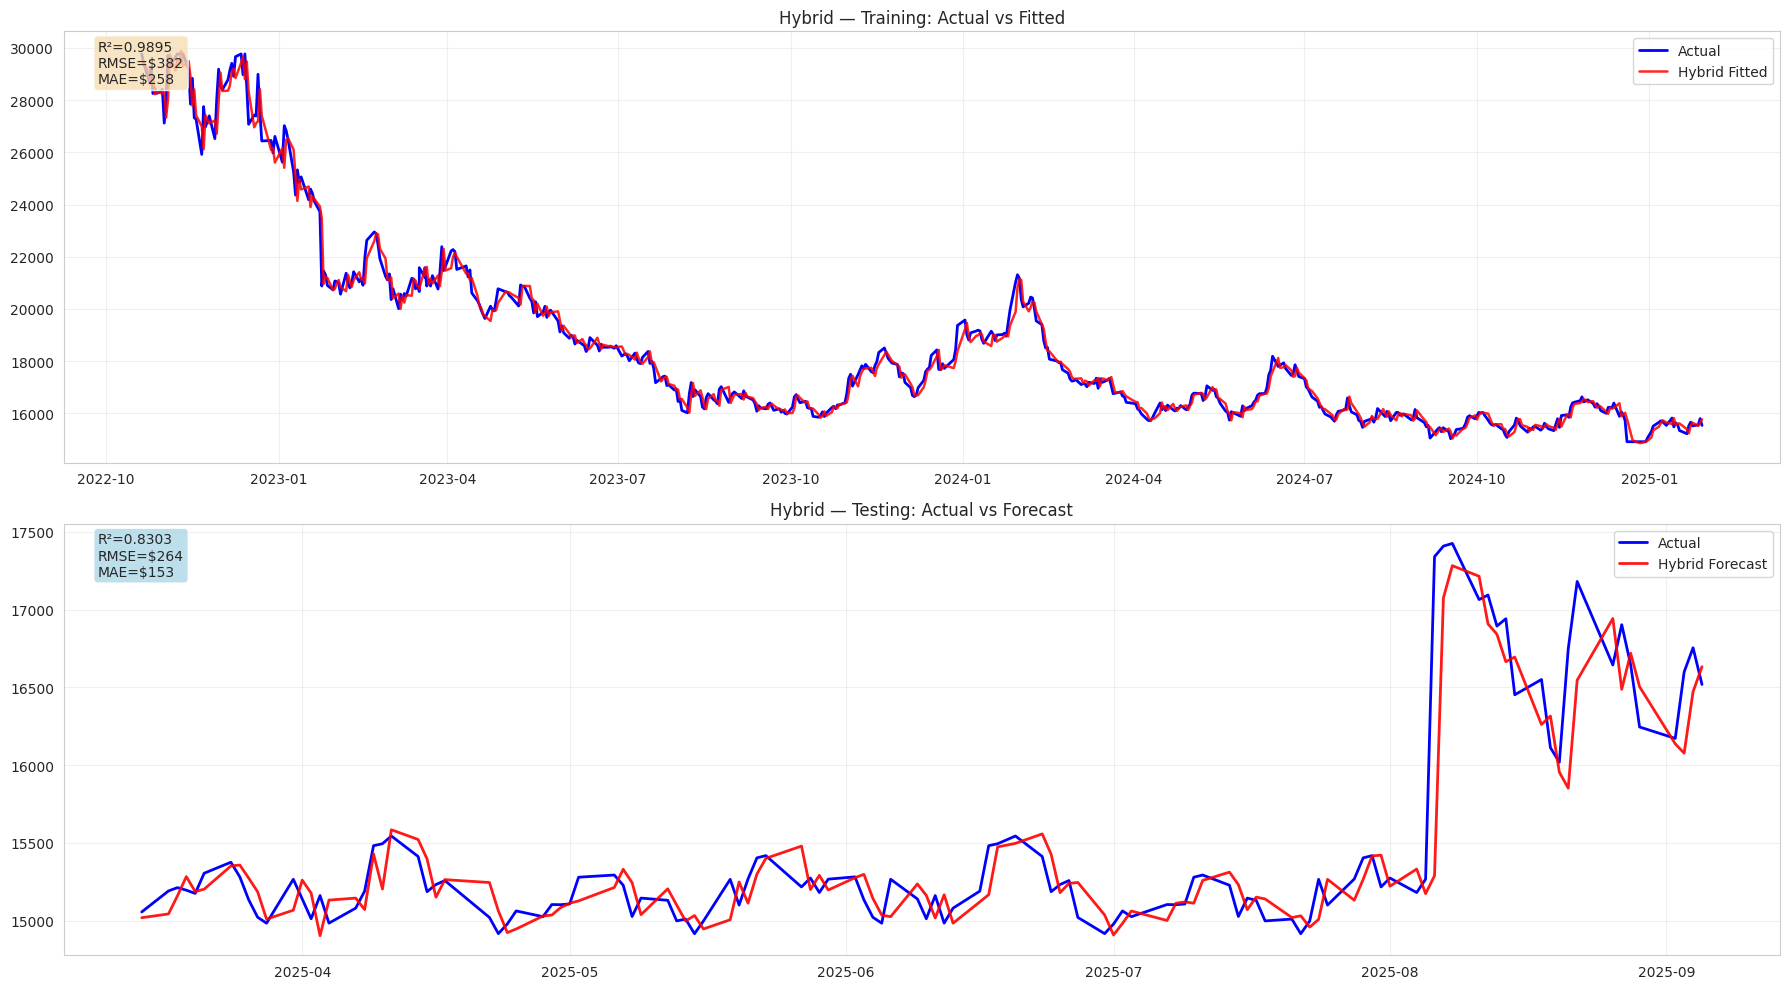

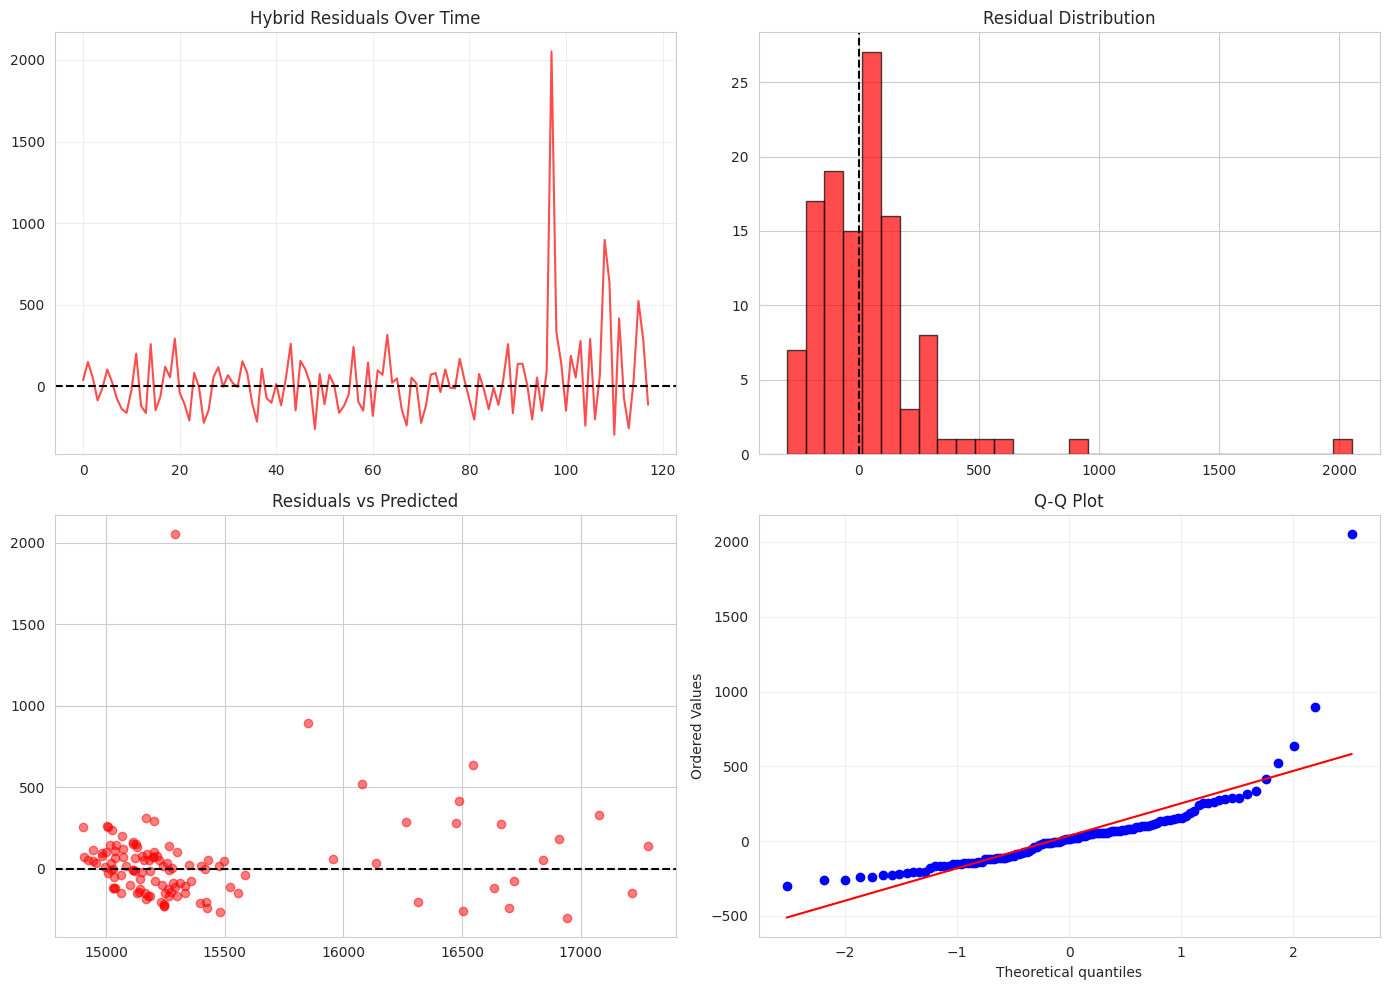


=== RINGKASAN HYBRID ===
Model                        RMSE          MAE         R²       MAPE
------------------------------------------------------------------
Hybrid               $     264.47 $     152.75     0.8303      0.96%


In [ ]:
# 7. HYBRID ARIMAX + CNN-LSTM
try:
    gdown.download(url, "data.csv", quiet=False)
except Exception:
    pass

df = pd.read_csv("data.csv")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.set_index('Date').sort_index()[["Nickel", "SP500", "USD_IDR", "stock"]]
df = df.drop(df.loc["2020-01-05":"2022-09-05"].index).ffill().bfill()

# Winsorization
for col in df.columns:
    df[col] = df[col].clip(df[col].quantile(0.01), df[col].quantile(0.99))
print(f"Hybrid — Data: {len(df)} sampel")

# Variabel eksogen d_SP500 (Box-Cox + differencing)
def boxcox_transform(series):
    shift = abs(series.min()) + 1 if series.min() <= 0 else 0
    transformed, lam = boxcox(np.array(series) + shift)
    return transformed, lam, shift

df["bc_SP500"], lam_sp, shift_sp = boxcox_transform(df["SP500"].values)
df["d_SP500"] = pd.Series(df["bc_SP500"]).diff()
df = df.dropna()
best_exog = "d_SP500"

# Train-test split 80/20
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]
y_train, y_test   = train["Nickel"], test["Nickel"]
X_train, X_test   = train[[best_exog]], test[[best_exog]]
print(f"Train: {len(train)} | Test: {len(test)}")

# Outlier visualization (sebelum & sesudah winsorization sudah dilakukan)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for idx, col in enumerate(['Nickel', 'SP500', 'USD_IDR', 'stock']):
    axes[idx].boxplot([df[col].dropna()], labels=[col], patch_artist=True,
                       boxprops=dict(facecolor='lightblue'))
    axes[idx].set_title(f'{col} — Boxplot (Setelah Winsorization)')
    axes[idx].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/outliers_after.png', dpi=150, bbox_inches='tight')
plt.show()

# Time series + korelasi
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
for idx, col in enumerate(['Nickel', 'SP500', 'USD_IDR', 'stock']):
    axes[idx].plot(df.index, df[col], linewidth=1.5)
    axes[idx].set_title(col); axes[idx].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/time_series_all.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df[['Nickel','SP500','USD_IDR','stock']].corr(), annot=True, fmt='.3f',
            cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ARIMAX(1,1,0)
print("\n=== HYBRID — STEP 1: ARIMAX(1,1,0) ===")
HYBRID_ORDER = (1, 1, 0)
best_order   = HYBRID_ORDER

best_model = SARIMAX(y_train, exog=X_train, order=HYBRID_ORDER,
                     enforce_stationarity=False, enforce_invertibility=False
                     ).fit(disp=False, maxiter=200, warn_convergence=False)
print(best_model.summary())
arimax_train_pred = best_model.fittedvalues

print("\nvalidation...")
t_start = time.time()
arimax_test_pred = []
for i in range(len(test)):
    y_ext = pd.concat([y_train, y_test.iloc[:i]]) if i > 0 else y_train
    X_ext = pd.concat([X_train, X_test.iloc[:i]]) if i > 0 else X_train
    try:
        r_wf = SARIMAX(y_ext, exog=X_ext, order=HYBRID_ORDER,
                       enforce_stationarity=False, enforce_invertibility=False
                       ).fit(disp=False, maxiter=200, warn_convergence=False)
        arimax_test_pred.append(r_wf.forecast(steps=1, exog=X_test.iloc[i:i+1]).values[0])
    except Exception:
        arimax_test_pred.append(best_model.forecast(steps=1, exog=X_test.iloc[i:i+1]).values[0])
    if (i+1) % 20 == 0:
        print(f"  {i+1}/{len(test)} ({time.time()-t_start:.1f}s)")
arimax_test_pred = pd.Series(arimax_test_pred, index=test.index)
print(f"Walk-forward selesai ({time.time()-t_start:.1f}s)")

def calculate_metrics(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-10))) * 100
    print(f"Selesai")
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

# Simpan metrik ARIMAX (digunakan untuk pkl & ringkasan, tanpa ditampilkan)
arimax_train_metrics = calculate_metrics(y_train.values, arimax_train_pred.values, "ARIMAX Train (Hybrid)")
arimax_test_metrics  = calculate_metrics(y_test.values,  arimax_test_pred.values,  "ARIMAX Test  (Hybrid)")

# CNN-LSTM untuk residual ARIMAX
print("\n=== HYBRID — STEP 2: CNN-LSTM RESIDUAL MODEL ===")
LOOKBACK = 30
train_residuals = (y_train - arimax_train_pred).values
test_residuals  = (y_test  - arimax_test_pred ).values

resid_scaler = StandardScaler()
train_resid_scaled = resid_scaler.fit_transform(train_residuals.reshape(-1, 1)).flatten()
test_resid_scaled  = resid_scaler.transform(test_residuals.reshape(-1, 1)).flatten()

X_resid_tr, y_resid_tr = build_sequences(train_resid_scaled, LOOKBACK)
X_resid_te, y_resid_te = build_sequences(test_resid_scaled,  LOOKBACK)

_W_HYB = 'models/cnn_lstm_residual.weights.h5'
_J_HYB = 'models/cnn_lstm_residual.json'

model_cnn_lstm = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(LOOKBACK, 1), padding='same'),
    Conv1D(64, 3, activation='relu', padding='same'),
    MaxPooling1D(2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
], name='CNN_LSTM_Residual')
model_cnn_lstm.compile(
    loss='huber', optimizer=Adam(learning_rate=0.0001, epsilon=1e-8), metrics=['mae']
)
model_cnn_lstm.summary()

cnn_start = time.time()
cb_hybrid = [
    EarlyStopping('val_loss', patience=100, restore_best_weights=True, verbose=1),
    ModelCheckpoint(_W_HYB, monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=30, min_lr=1e-6, verbose=1)
]
history_cnn = model_cnn_lstm.fit(
    X_resid_tr, y_resid_tr, epochs=1000, batch_size=32,
    validation_split=0.15, shuffle=False, callbacks=cb_hybrid, verbose=1
)
cnn_training_time = time.time() - cnn_start
print(f"\nCNN-LSTM selesai ({cnn_training_time:.1f}s | {cnn_training_time/60:.1f} menit)")

with open(_J_HYB, 'w') as f:
    json.dump(model_cnn_lstm.to_json(), f)
model_cnn_lstm.save_weights(_W_HYB)

# Prediksi residual
cnn_train_pred_scaled = model_cnn_lstm.predict(X_resid_tr, verbose=0)
cnn_test_pred_scaled  = model_cnn_lstm.predict(X_resid_te, verbose=0)
cnn_train_pred = resid_scaler.inverse_transform(cnn_train_pred_scaled).flatten()
cnn_test_pred  = resid_scaler.inverse_transform(cnn_test_pred_scaled).flatten()

# Selaraskan indeks (potong LOOKBACK awal)
y_train_aligned = y_train.values[LOOKBACK:]
y_test_aligned  = y_test.values[LOOKBACK:]
arimax_train_al = arimax_train_pred.values[LOOKBACK:]
arimax_test_al  = arimax_test_pred.values[LOOKBACK:]

# Prediksi Hybrid = ARIMAX + CNN-LSTM residual
hybrid_train = arimax_train_al + cnn_train_pred
hybrid_test  = arimax_test_al  + cnn_test_pred

print("\n=== EVALUASI HYBRID ===")
cnn_train_metrics    = calculate_metrics(train_residuals[LOOKBACK:], cnn_train_pred,  "CNN-LSTM Residual Train")
cnn_test_metrics     = calculate_metrics(test_residuals[LOOKBACK:],  cnn_test_pred,   "CNN-LSTM Residual Test")
hybrid_train_metrics = calculate_metrics(y_train_aligned, hybrid_train, "Hybrid Train")
hybrid_test_metrics  = calculate_metrics(y_test_aligned,  hybrid_test,  "Hybrid Test")

# Visualisasi Training History CNN-LSTM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_cnn.history['loss'], label='Train'); axes[0].plot(history_cnn.history['val_loss'], label='Val')
axes[0].set_title('CNN-LSTM Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_cnn.history['mae'], label='Train'); axes[1].plot(history_cnn.history['val_mae'], label='Val')
axes[1].set_title('CNN-LSTM MAE'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/cnn_lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Visualisasi Hybrid vs Actual
train_dates_comp = y_train.index[LOOKBACK:]
test_dates_comp  = y_test.index[LOOKBACK:]

fig, axes = plt.subplots(2, 1, figsize=(18, 10))
axes[0].plot(train_dates_comp, y_train_aligned, 'b-', label='Actual', linewidth=2)
axes[0].plot(train_dates_comp, hybrid_train, 'r-', label='Hybrid Fitted', linewidth=1.8, alpha=0.85)
axes[0].set_title('Hybrid — Training: Actual vs Fitted'); axes[0].legend(); axes[0].grid(alpha=0.3)
m = hybrid_train_metrics
axes[0].text(0.02, 0.98, f"R²={m['R2']:.4f}\nRMSE=${m['RMSE']:.0f}\nMAE=${m['MAE']:.0f}",
             transform=axes[0].transAxes, fontsize=10, va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

axes[1].plot(test_dates_comp, y_test_aligned, 'b-', label='Actual', linewidth=2)
axes[1].plot(test_dates_comp, hybrid_test, 'r-', label='Hybrid Forecast', linewidth=2, alpha=0.9)
axes[1].set_title('Hybrid — Testing: Actual vs Forecast'); axes[1].legend(); axes[1].grid(alpha=0.3)
m = hybrid_test_metrics
axes[1].text(0.02, 0.98, f"R²={m['R2']:.4f}\nRMSE=${m['RMSE']:.0f}\nMAE=${m['MAE']:.0f}",
             transform=axes[1].transAxes, fontsize=10, va='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
plt.tight_layout()
plt.savefig('figures/comparison_value_vs_fitted_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Residual analysis
residuals_hybrid = y_test_aligned - hybrid_test
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(residuals_hybrid, color='red', alpha=0.7); axes[0,0].axhline(0, color='black', linestyle='--')
axes[0,0].set_title('Hybrid Residuals Over Time'); axes[0,0].grid(alpha=0.3)
axes[0,1].hist(residuals_hybrid, bins=30, color='red', alpha=0.7, edgecolor='black')
axes[0,1].axvline(0, color='black', linestyle='--'); axes[0,1].set_title('Residual Distribution')
axes[1,0].scatter(hybrid_test, residuals_hybrid, alpha=0.5, color='red')
axes[1,0].axhline(0, color='black', linestyle='--'); axes[1,0].set_title('Residuals vs Predicted')
from scipy import stats
stats.probplot(residuals_hybrid, dist="norm", plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot'); axes[1,1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/residuals_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Simpan semua prediksi Hybrid
with open('output/hybrid_predictions.pkl', 'wb') as f:
    pickle.dump({
        'train_dates':      list(train_dates_comp.astype(str)),
        'test_dates':       list(test_dates_comp.astype(str)),
        'y_train_actual':   y_train_aligned,
        'y_test_actual':    y_test_aligned,
        'hybrid_train':     hybrid_train,
        'hybrid_test':      hybrid_test,
        'arimax_train_metrics': arimax_train_metrics,
        'arimax_test_metrics':  arimax_test_metrics,
        'hybrid_train_metrics': hybrid_train_metrics,
        'hybrid_test_metrics':  hybrid_test_metrics,
    }, f)

# Simpan metrik ringkasan
with open('output/all_metrics.json', 'w') as f:
    json.dump({
        'arimax': {'train': arimax_train_metrics, 'test': arimax_test_metrics},
        'cnn_lstm_residual': {'train': cnn_train_metrics, 'test': cnn_test_metrics},
        'hybrid': {'train': hybrid_train_metrics, 'test': hybrid_test_metrics},
        'diagnostics': {
            'arimax_order': str(best_order), 'exog': best_exog,
            'cnn_lstm_epochs': len(history_cnn.history['loss']),
            'residual_mean': float(residuals_hybrid.mean()),
            'residual_std':  float(residuals_hybrid.std())
        }
    }, f, indent=4)

print("\n=== RINGKASAN HYBRID ===")
print(f"{'Model':<20} {'RMSE':>12} {'MAE':>12} {'R²':>10} {'MAPE':>10}")
print("-" * 66)
print(f"{'Hybrid':<20} ${hybrid_test_metrics['RMSE']:>11.2f} ${hybrid_test_metrics['MAE']:>11.2f} "
      f"{hybrid_test_metrics['R2']:>10.4f} {hybrid_test_metrics['MAPE']:>9.2f}%")

STEP 1: Re-fit ARIMAX pada data train + test (seluruh data)
Re-fit selesai. Data: 740 obs | Order: (1, 1, 0)
Eksogen d_SP500: 20 hari pakai nilai aktual, 10 hari pakai konstanta (0.024686)
Periode forecast: 2025-09-08 s/d 2025-10-17 (hari kerja, tanpa Sabtu-Minggu)
ARIMAX forecast 30 hari kerja selesai.
  Level koreksi : -1251.90 (model=16,519.03 | aktual=15,267.13)

STEP 2: CNN-LSTM Rolling Forecast pada Residual
CNN-LSTM residual forecast selesai (30 langkah).

=== TABEL GABUNGAN: ESTIMASI TESTING + FORECAST 30 HARI KERJA ===
Rentang  : 2025-03-14 s/d 2025-10-17
Testing  : 118 baris | Forecast: 30 baris (tanpa Sabtu-Minggu)

              Aktual  Hybrid_Estimasi  ARIMAX_Forecast  Residual_CNNLSTM  Hybrid_Forecast Keterangan
Date                                                                                                
2025-03-14  15056.13         15019.24              NaN               NaN              NaN    Testing
2025-03-17  15191.25         15043.33              NaN        

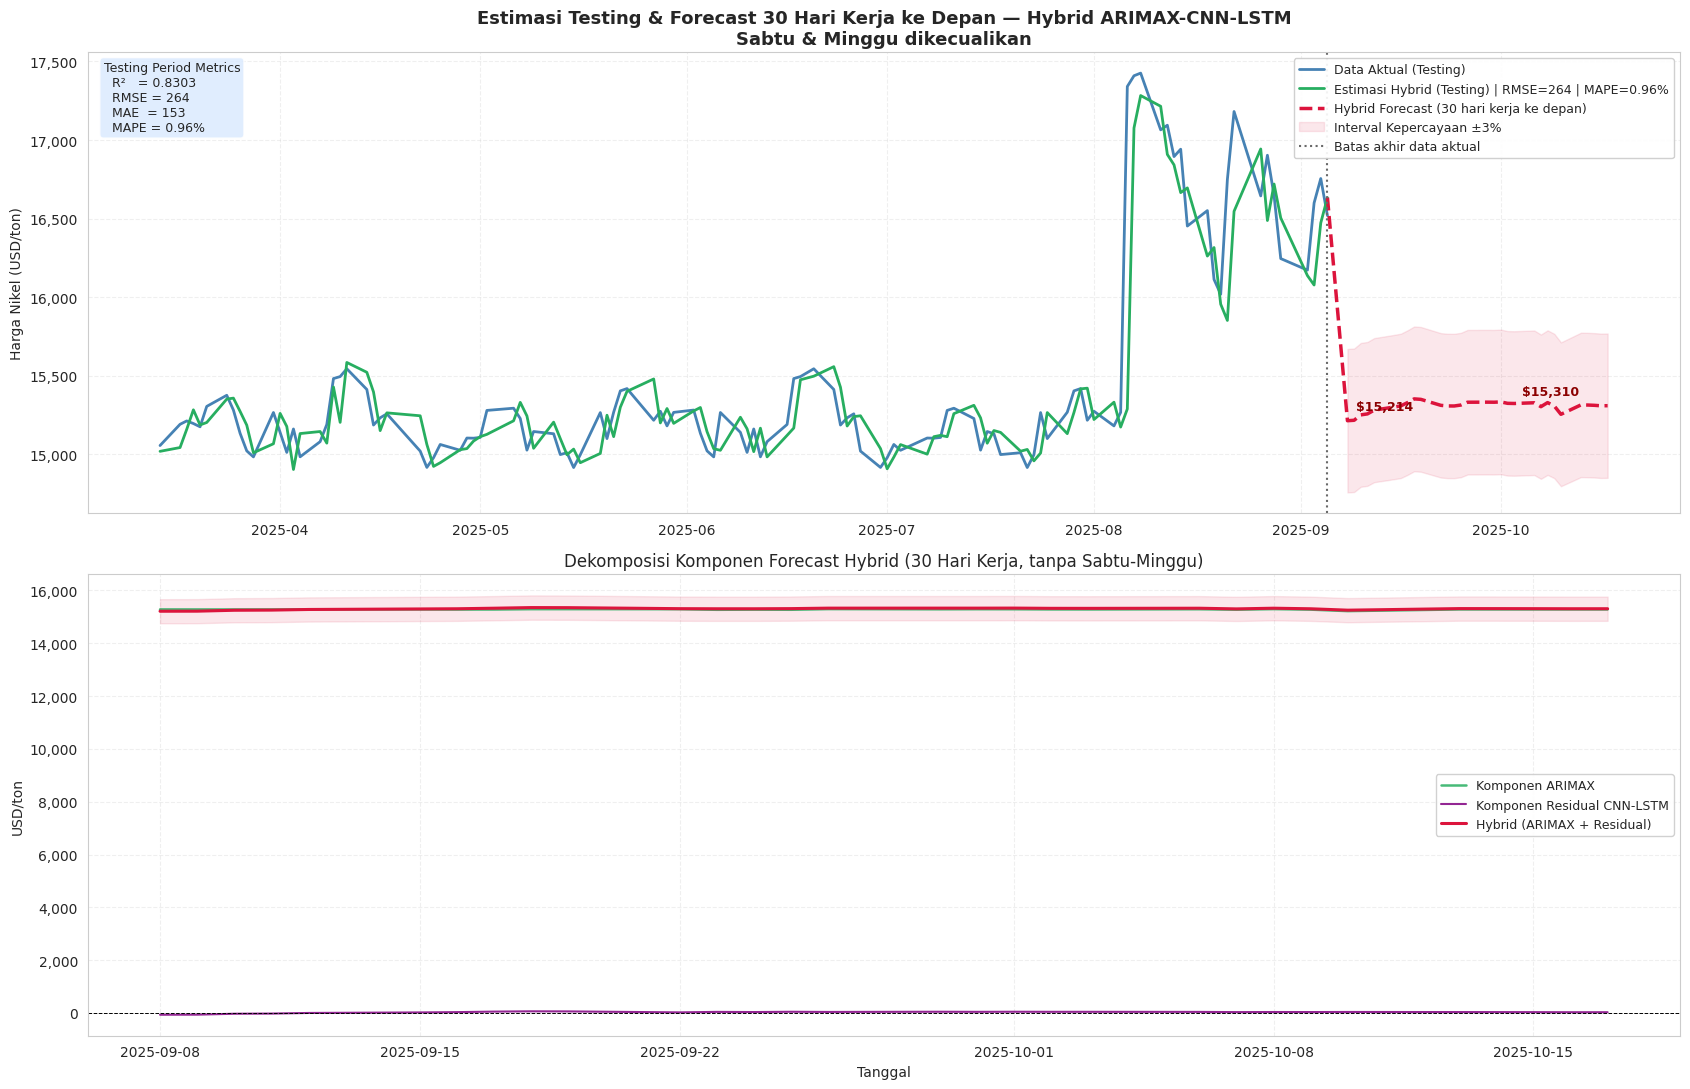


  RINGKASAN FORECAST 30 HARI KERJA KE DEPAN (Tanpa Sabtu-Minggu)
  Periode    : 2025-09-08 s/d 2025-10-17
  Harga awal : USD  15,214.14/ton  (Hari ke-1)
  Harga akhir: USD  15,309.65/ton  (Hari ke-30)
  Rata-rata  : USD  15,305.50/ton
  Minimum    : USD  15,214.14/ton
  Maksimum   : USD  15,352.95/ton
  Perubahan  : +95.51 USD/ton (+0.63%) — Naik
  Asumsi eksogen: d_SP500 = 0.024686
  Estimasi Testing  : 118 titik data (RMSE=264)
  Forecast Ke depan : 30 hari kerja


In [ ]:
# ============================================================
# 8. FORECAST 30 HARI KE DEPAN — Model Hybrid ARIMAX-CNN-LSTM
# Estimasi Testing + Out-of-sample Forecast 30 Hari Ke Depan
# Sabtu & Minggu dikecualikan (freq='B' = hari kerja saja)
# ============================================================

N_FORECAST = 30

# ── Step 1: Re-fit ARIMAX pada seluruh data (train + test) ──
print("=" * 60)
print("STEP 1: Re-fit ARIMAX pada data train + test (seluruh data)")
print("=" * 60)
y_all = pd.concat([y_train, y_test])
X_all = pd.concat([X_train, X_test])

final_arimax = SARIMAX(
    y_all, exog=X_all, order=best_order,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False, maxiter=200, warn_convergence=False)
print(f"Re-fit selesai. Data: {len(y_all)} obs | Order: {best_order}")

# Asumsi eksogen default: rata-rata d_SP500 dari 30 hari kerja terakhir test
exog_future_val = float(X_all[best_exog].tail(30).mean())
last_date       = y_all.index[-1]
future_dates    = pd.date_range(last_date + pd.offsets.BDay(1), periods=N_FORECAST, freq='B')
exog_future     = pd.DataFrame({best_exog: [exog_future_val] * N_FORECAST}, index=future_dates)

# ── Gunakan d_SP500 aktual untuk hari yang datanya sudah diketahui ──────
# Close price SP500 aktual (08/09 – 10/10/2025)
SP500_ACTUAL_FC = {
    '2025-09-15': 6615.28, '2025-09-16': 6606.76, '2025-09-17': 6600.35,
    '2025-09-18': 6631.96, '2025-09-19': 6664.36, '2025-09-22': 6693.75,
    '2025-09-23': 6656.92, '2025-09-24': 6637.97, '2025-09-25': 6604.72,
    '2025-09-26': 6643.70, '2025-09-29': 6661.21, '2025-09-30': 6688.46,
    '2025-10-01': 6711.20, '2025-10-02': 6715.35, '2025-10-03': 6715.79,
    '2025-10-06': 6740.28, '2025-10-07': 6714.59, '2025-10-08': 6753.72,
    '2025-10-09': 6735.11, '2025-10-10': 6552.51,
}
_sp500_s       = pd.Series(SP500_ACTUAL_FC, dtype=float)
_sp500_s.index = pd.to_datetime(_sp500_s.index)

# Terapkan Box-Cox yang sama dari training: bc = ((x + shift)^lam - 1) / lam
_bc_arr = ((_sp500_s.values + shift_sp) ** lam_sp - 1) / lam_sp

# d_SP500 antar hari konsekutif; hari pertama (15/09) tetap pakai konstanta
# karena tidak ada SP500 12/09 untuk menghitung selisihnya
_d_arr = np.concatenate([[exog_future_val], np.diff(_bc_arr)])
_d_sp500_actual = pd.Series(_d_arr, index=_sp500_s.index, name=best_exog)

# Override eksogen pada tanggal yang tersedia dalam future_dates
for _dt, _val in _d_sp500_actual.items():
    if _dt in exog_future.index:
        exog_future.loc[_dt, best_exog] = _val

n_override = int(exog_future.index.isin(_sp500_s.index).sum())
print(f"Eksogen d_SP500: {n_override} hari pakai nilai aktual, "
      f"{N_FORECAST - n_override} hari pakai konstanta ({exog_future_val:.6f})")
print(f"Periode forecast: {future_dates[0].date()} s/d {future_dates[-1].date()} (hari kerja, tanpa Sabtu-Minggu)")

arimax_forecast_30_raw = final_arimax.forecast(steps=N_FORECAST, exog=exog_future)

# ── Koreksi Level (Level Anchoring) ──────────────────────────
# ARIMA(d=1) dengan eksogen konstan menghasilkan forecast yang
# konvergen ke satu nilai tetap (long-run level = y_all[-1] + drift).
# Jika y_all[-1] berbeda dari harga pasar aktual, perlu koreksi level
# agar forecast "bertolak" dari harga aktual yang benar.
ACTUAL_LAST_PRICE = 15267.13   # harga aktual Nikel 05/09/2025 (USD/ton)
model_last_price  = float(y_all.iloc[-1])
level_offset      = ACTUAL_LAST_PRICE - model_last_price
arimax_forecast_30 = arimax_forecast_30_raw + level_offset
print(f"ARIMAX forecast {N_FORECAST} hari kerja selesai.")
print(f"  Level koreksi : {level_offset:+.2f} (model={model_last_price:,.2f} | aktual={ACTUAL_LAST_PRICE:,.2f})")

# ── Step 2: CNN-LSTM Rolling Residual Forecast ──────────────
print("\n" + "=" * 60)
print("STEP 2: CNN-LSTM Rolling Forecast pada Residual")
print("=" * 60)
last_window_scaled = resid_scaler.transform(
    test_residuals[-LOOKBACK:].reshape(-1, 1)
).flatten()

future_resid_scaled = []
window = last_window_scaled.copy()
for step in range(N_FORECAST):
    x_in   = window.reshape(1, LOOKBACK, 1)
    pred_s = float(model_cnn_lstm.predict(x_in, verbose=0)[0, 0])
    future_resid_scaled.append(pred_s)
    window = np.append(window[1:], pred_s)

future_resid = resid_scaler.inverse_transform(
    np.array(future_resid_scaled).reshape(-1, 1)
).flatten()
print(f"CNN-LSTM residual forecast selesai ({N_FORECAST} langkah).")

# ── Step 3: Gabungkan → Hybrid Forecast ─────────────────────
hybrid_forecast_30 = arimax_forecast_30.values + future_resid

# ── Step 4: Buat DataFrame GABUNGAN (Testing + Forecast) ────
# --- Bagian testing period ---
df_testing_part = pd.DataFrame({
    'Aktual':           y_test_aligned,
    'Hybrid_Estimasi':  hybrid_test,
    'ARIMAX_Forecast':  np.nan,
    'Residual_CNNLSTM': np.nan,
    'Hybrid_Forecast':  np.nan,
    'Keterangan':       'Testing',
}, index=test_dates_comp)

# --- Bagian forecast 30 hari ke depan (hari kerja, tanpa Sabtu-Minggu) ---
df_future_part = pd.DataFrame({
    'Aktual':           np.nan,
    'Hybrid_Estimasi':  np.nan,
    'ARIMAX_Forecast':  arimax_forecast_30.values,
    'Residual_CNNLSTM': future_resid,
    'Hybrid_Forecast':  hybrid_forecast_30,
    'Keterangan':       'Forecast',
}, index=future_dates)

df_combined = pd.concat([df_testing_part, df_future_part])
df_combined.index.name = 'Date'

print("\n=== TABEL GABUNGAN: ESTIMASI TESTING + FORECAST 30 HARI KERJA ===")
print(f"Rentang  : {df_combined.index[0].date()} s/d {df_combined.index[-1].date()}")
print(f"Testing  : {len(df_testing_part)} baris | Forecast: {len(df_future_part)} baris (tanpa Sabtu-Minggu)")
print()
print(df_combined.round(2).to_string())

# ── Step 5: Visualisasi ──────────────────────────────────────
last_hybrid_date = test_dates_comp[-1]
last_hybrid_val  = float(hybrid_test[-1])
fc_join_dates    = pd.DatetimeIndex([last_hybrid_date]).append(future_dates)
fc_join_values   = np.concatenate([[last_hybrid_val], hybrid_forecast_30])

fig, axes = plt.subplots(2, 1, figsize=(17, 11))

# ── Panel atas: Testing Aktual & Estimasi + Forecast (menyatu) ──
axes[0].plot(test_dates_comp, y_test_aligned,
             color='steelblue', linewidth=2.0,
             label='Data Aktual (Testing)')
axes[0].plot(test_dates_comp, hybrid_test,
             color='#27ae60', linewidth=2.0,
             label=(f'Estimasi Hybrid (Testing) | '
                    f'RMSE={hybrid_test_metrics["RMSE"]:,.0f} | '
                    f'MAPE={hybrid_test_metrics["MAPE"]:.2f}%'))
axes[0].plot(fc_join_dates, fc_join_values,
             color='crimson', linewidth=2.5, linestyle='--',
             label=f'Hybrid Forecast ({N_FORECAST} hari kerja ke depan)')
axes[0].fill_between(future_dates,
                     hybrid_forecast_30 * 0.97, hybrid_forecast_30 * 1.03,
                     color='crimson', alpha=0.10, label='Interval Kepercayaan ±3%')
axes[0].axvline(last_hybrid_date, color='dimgray', linestyle=':', linewidth=1.5,
                label='Batas akhir data aktual')
axes[0].annotate(f"${hybrid_forecast_30[0]:,.0f}",
                 xy=(future_dates[0], hybrid_forecast_30[0]),
                 xytext=(6, 8), textcoords='offset points',
                 fontsize=9, color='darkred', fontweight='bold')
axes[0].annotate(f"${hybrid_forecast_30[-1]:,.0f}",
                 xy=(future_dates[-1], hybrid_forecast_30[-1]),
                 xytext=(-62, 8), textcoords='offset points',
                 fontsize=9, color='darkred', fontweight='bold')
axes[0].text(0.01, 0.98,
             (f"Testing Period Metrics\n"
              f"  R²   = {hybrid_test_metrics['R2']:.4f}\n"
              f"  RMSE = {hybrid_test_metrics['RMSE']:,.0f}\n"
              f"  MAE  = {hybrid_test_metrics['MAE']:,.0f}\n"
              f"  MAPE = {hybrid_test_metrics['MAPE']:.2f}%"),
             transform=axes[0].transAxes, fontsize=9, va='top',
             bbox=dict(boxstyle='round', facecolor='#dbeafe', alpha=0.85))
axes[0].set_title(
    'Estimasi Testing & Forecast 30 Hari Kerja ke Depan — Hybrid ARIMAX-CNN-LSTM\n'
    'Sabtu & Minggu dikecualikan',
    fontsize=13, fontweight='bold')
axes[0].set_ylabel('Harga Nikel (USD/ton)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].legend(loc='upper right', fontsize=9, framealpha=0.92)
axes[0].grid(True, alpha=0.3, linestyle='--')

# ── Panel bawah: dekomposisi komponen forecast ───────────────
axes[1].plot(future_dates, arimax_forecast_30.values,
             color='#27ae60', linewidth=1.8, label='Komponen ARIMAX', alpha=0.85)
axes[1].plot(future_dates, future_resid,
             color='purple', linewidth=1.5, label='Komponen Residual CNN-LSTM', alpha=0.85)
axes[1].plot(future_dates, hybrid_forecast_30,
             color='crimson', linewidth=2.2, label='Hybrid (ARIMAX + Residual)', zorder=5)
axes[1].fill_between(future_dates, hybrid_forecast_30 * 0.97, hybrid_forecast_30 * 1.03,
                     color='crimson', alpha=0.10)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.7)
axes[1].set_title('Dekomposisi Komponen Forecast Hybrid (30 Hari Kerja, tanpa Sabtu-Minggu)',
                  fontsize=12)
axes[1].set_ylabel('USD/ton')
axes[1].set_xlabel('Tanggal')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].legend(fontsize=9, framealpha=0.9)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('figures/hybrid_forecast_30days.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ringkasan ────────────────────────────────────────────────
trend = 'Naik' if hybrid_forecast_30[-1] > hybrid_forecast_30[0] else 'Turun'
chg   = hybrid_forecast_30[-1] - hybrid_forecast_30[0]
chg_p = chg / hybrid_forecast_30[0] * 100

print(f"\n{'='*65}")
print(f"  RINGKASAN FORECAST {N_FORECAST} HARI KERJA KE DEPAN (Tanpa Sabtu-Minggu)")
print(f"{'='*65}")
print(f"  Periode    : {future_dates[0].date()} s/d {future_dates[-1].date()}")
print(f"  Harga awal : USD {hybrid_forecast_30[0]:>10,.2f}/ton  (Hari ke-1)")
print(f"  Harga akhir: USD {hybrid_forecast_30[-1]:>10,.2f}/ton  (Hari ke-{N_FORECAST})")
print(f"  Rata-rata  : USD {hybrid_forecast_30.mean():>10,.2f}/ton")
print(f"  Minimum    : USD {hybrid_forecast_30.min():>10,.2f}/ton")
print(f"  Maksimum   : USD {hybrid_forecast_30.max():>10,.2f}/ton")
print(f"  Perubahan  : {chg:+,.2f} USD/ton ({chg_p:+.2f}%) — {trend}")
print(f"  Asumsi eksogen: {best_exog} = {exog_future_val:.6f}")
print(f"{'='*65}")
print(f"  Estimasi Testing  : {len(df_testing_part)} titik data (RMSE={hybrid_test_metrics['RMSE']:,.0f})")
print(f"  Forecast Ke depan : {N_FORECAST} hari kerja")
print(f"{'='*65}")



  GRAFIK PERBANDINGAN: ARIMAX | LSTM | CNN | ARIMAX+CNN-LSTM
Data: 741 sampel | Test DL offset: 119 sampel
ARIMAX: RMSE=651.66 | MAE=537.80 | R²=-0.0329 | MAPE=3.41%
LSTM:   RMSE=392.87 | MAE=265.16 | R²=0.6246 | MAPE=1.68%
CNN:    RMSE=489.88 | MAE=398.93 | R²=0.4163 | MAPE=2.56%
Hybrid: RMSE=264.47 | MAE=152.75 | R²=0.8303 | MAPE=0.96%


IndexError: list index out of range

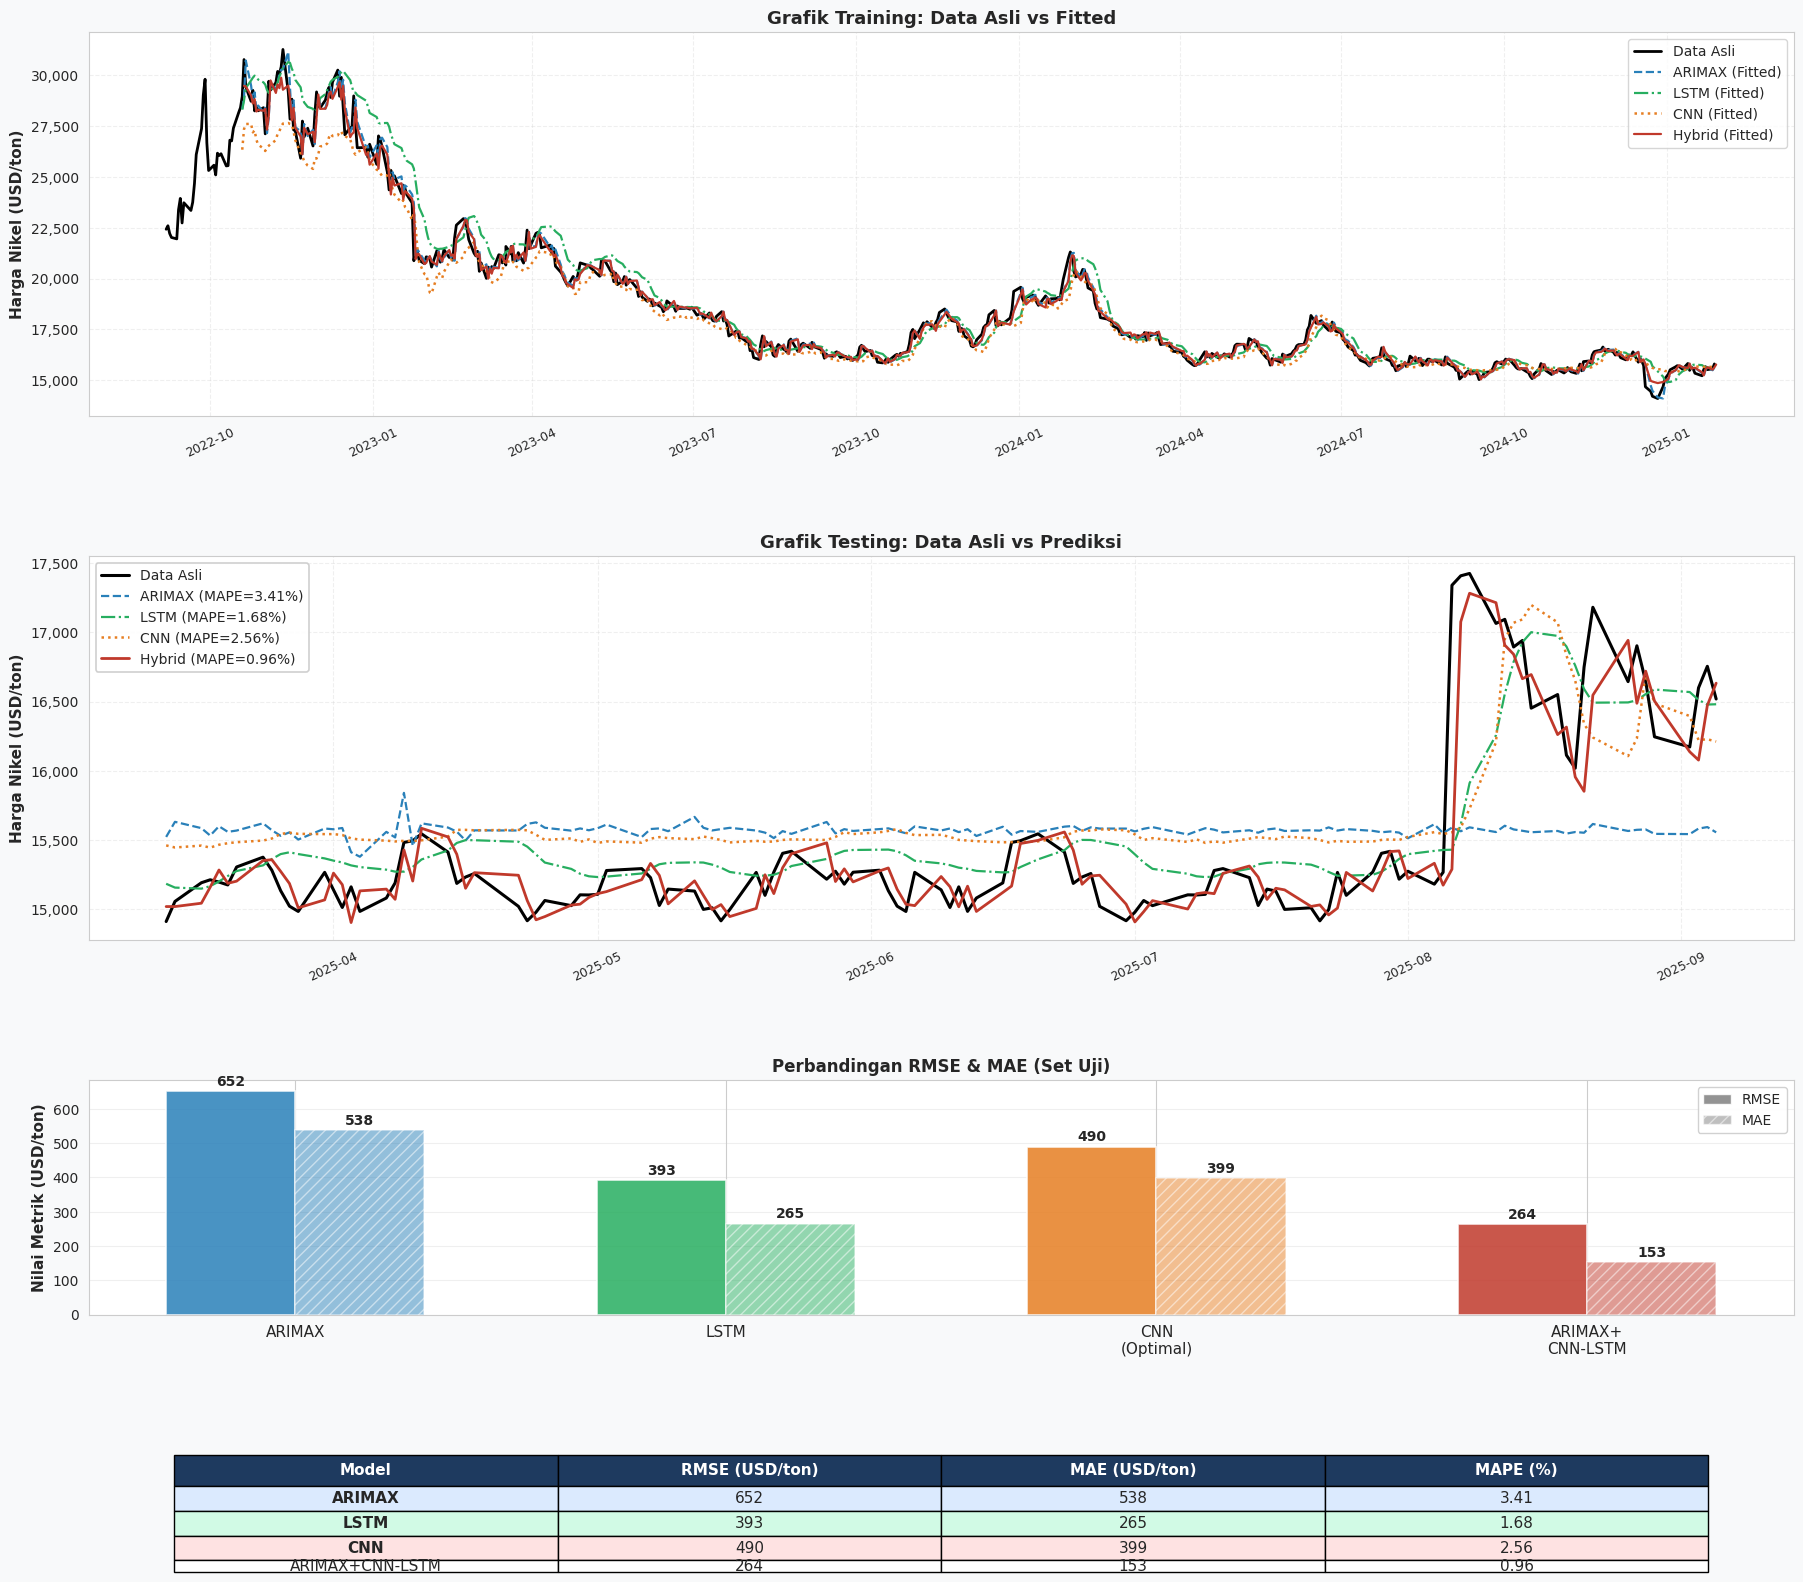

In [ ]:

# 8. PERBANDINGAN SEMUA MODEL
"""
Memuat hasil tersimpan dari semua model:
  • LSTM   → output/predictions_default.pkl
  • CNN    → output/predictions_optimal.pkl
  • Hybrid → output/hybrid_predictions.pkl
  • ARIMAX → dijalankan ulang (tidak ada pkl)
"""
warnings.filterwarnings('ignore')
for d in ['output', 'figures']:
    os.makedirs(d, exist_ok=True)

print("\n" + "="*65)
print("  GRAFIK PERBANDINGAN: ARIMAX | LSTM | CNN | ARIMAX+CNN-LSTM")
print("="*65)

# Load data
df_raw = pd.read_csv("data.csv")
df_raw['Date'] = pd.to_datetime(df_raw['Date'], errors='coerce')
df_raw = df_raw.set_index('Date').sort_index()[["Nickel", "SP500", "USD_IDR", "stock"]]
df_raw = df_raw.drop(df_raw.loc["2020-01-05":"2022-09-05"].index).ffill().bfill()

SPLIT_IDX   = int(len(df_raw) * 0.8)
data_train  = df_raw.iloc[:SPLIT_IDX]
data_test   = df_raw.iloc[SPLIT_IDX:]
test_dates_dl = data_test.index[WINDOW:]
actual_dl     = data_test['Nickel'].iloc[WINDOW:].values
train_dates_dl = data_train.index[WINDOW:]
print(f"Data: {len(df_raw)} sampel | Test DL offset: {len(test_dates_dl)} sampel")

# [1/4] ARIMAX (jalankan ulang)
df_ax2 = df_raw.copy()
df_ax2["bc_SP500"], _, _ = boxcox_transform(df_ax2["SP500"])
df_ax2["d_SP500"] = pd.Series(df_ax2["bc_SP500"]).diff()
df_ax2 = df_ax2.dropna()
n2 = int(len(df_ax2) * 0.8)
tr2, te2   = df_ax2.iloc[:n2], df_ax2.iloc[n2:]
arimax_m2  = SARIMAX(tr2["Nickel"], exog=tr2[["d_SP500"]], order=(1,1,0),
                     enforce_stationarity=False, enforce_invertibility=False)
arimax_r2  = arimax_m2.fit(disp=False)
arimax_fcast2 = arimax_r2.predict(start=len(tr2), end=len(df_ax2)-1, exog=te2[["d_SP500"]])

arimax_fitted_raw = pd.Series(arimax_r2.fittedvalues.values, index=tr2.index)
arimax_fitted_raw = arimax_fitted_raw[~arimax_fitted_raw.index.duplicated(keep='first')]
arimax_fitted_tr  = arimax_fitted_raw.reindex(train_dates_dl).ffill().bfill()
if arimax_fitted_tr.isna().any():
    n_tr = min(len(arimax_r2.fittedvalues), len(train_dates_dl))
    arimax_fitted_tr = pd.Series(arimax_r2.fittedvalues.values[:n_tr],
                                  index=train_dates_dl[:n_tr]).reindex(train_dates_dl).ffill().bfill()

arimax_s   = pd.Series(arimax_fcast2.values, index=te2.index)
arimax_al  = arimax_s.reindex(test_dates_dl).ffill().bfill()
actual_ax2 = data_test['Nickel'].reindex(test_dates_dl).ffill().bfill()
rmse_ax, mae_ax, r2_ax, mape_ax = calc_metrics(actual_ax2.values, arimax_al.values)
print(f"ARIMAX: RMSE={rmse_ax:,.2f} | MAE={mae_ax:,.2f} | R²={r2_ax:.4f} | MAPE={mape_ax:.2f}%")

# [2/4] LSTM
PKL_LSTM = "output/predictions_default.pkl"
if not os.path.exists(PKL_LSTM):
    raise FileNotFoundError(f"'{PKL_LSTM}' tidak ditemukan. Jalankan bagian LSTM lebih dulu.")
with open(PKL_LSTM, 'rb') as f:
    lstm_data = pickle.load(f)
y_pred_lstm      = lstm_data['y_test_predicted'].flatten()
y_true_lstm      = lstm_data['y_test_actual'].flatten()
y_fitted_lstm_tr = lstm_data['y_train_fitted'].flatten()
n_l              = min(len(y_pred_lstm), len(test_dates_dl))
lstm_dates       = test_dates_dl[:n_l]
y_pred_lstm, y_true_lstm = y_pred_lstm[:n_l], y_true_lstm[:n_l]
n_lt             = min(len(y_fitted_lstm_tr), len(train_dates_dl))
lstm_train_dates = train_dates_dl[:n_lt]
y_fitted_lstm_tr = y_fitted_lstm_tr[:n_lt]
rmse_lstm, mae_lstm, r2_lstm, mape_lstm = calc_metrics(y_true_lstm, y_pred_lstm)
print(f"LSTM:   RMSE={rmse_lstm:,.2f} | MAE={mae_lstm:,.2f} | R²={r2_lstm:.4f} | MAPE={mape_lstm:.2f}%")

# [3/4] CNN Optimal
PKL_CNN = "output/predictions_optimal.pkl"
if not os.path.exists(PKL_CNN):
    raise FileNotFoundError(f"'{PKL_CNN}' tidak ditemukan. Jalankan bagian CNN lebih dulu.")
with open(PKL_CNN, 'rb') as f:
    cnn_data = pickle.load(f)
y_pred_cnn      = cnn_data['y_test_predicted'].flatten()
y_true_cnn      = cnn_data['y_test_actual'].flatten()
y_fitted_cnn_tr = cnn_data['y_train_fitted'].flatten()
n_c             = min(len(y_pred_cnn), len(test_dates_dl))
cnn_dates       = test_dates_dl[:n_c]
y_pred_cnn, y_true_cnn = y_pred_cnn[:n_c], y_true_cnn[:n_c]
n_ct            = min(len(y_fitted_cnn_tr), len(train_dates_dl))
cnn_train_dates = train_dates_dl[:n_ct]
y_fitted_cnn_tr = y_fitted_cnn_tr[:n_ct]
rmse_cnn, mae_cnn, r2_cnn, mape_cnn = calc_metrics(y_true_cnn, y_pred_cnn)
print(f"CNN:    RMSE={rmse_cnn:,.2f} | MAE={mae_cnn:,.2f} | R²={r2_cnn:.4f} | MAPE={mape_cnn:.2f}%")

# [4/4] Hybrid
PKL_HYB = "output/hybrid_predictions.pkl"
if not os.path.exists(PKL_HYB):
    raise FileNotFoundError(f"'{PKL_HYB}' tidak ditemukan. Jalankan bagian Hybrid lebih dulu.")
with open(PKL_HYB, 'rb') as f:
    hyb_data = pickle.load(f)
hybrid_dates     = pd.DatetimeIndex(hyb_data['test_dates'])
hybrid_pred      = np.array(hyb_data['hybrid_test']).flatten()
y_actual_hyb     = np.array(hyb_data['y_test_actual']).flatten()
hybrid_train_d   = pd.DatetimeIndex(hyb_data['train_dates'])
hybrid_fitted_tr = np.array(hyb_data['hybrid_train']).flatten()
rmse_hyb, mae_hyb, r2_hyb, mape_hyb = calc_metrics(y_actual_hyb, hybrid_pred)
print(f"Hybrid: RMSE={rmse_hyb:,.2f} | MAE={mae_hyb:,.2f} | R²={r2_hyb:.4f} | MAPE={mape_hyb:.2f}%")

# Simpan metrik gabungan
all_metrics_comp = {
    "ARIMAX":          {"RMSE": rmse_ax,   "MAE": mae_ax,   "MAPE": mape_ax},
    "LSTM":            {"RMSE": rmse_lstm,  "MAE": mae_lstm,  "MAPE": mape_lstm},
    "CNN_Optimal":     {"RMSE": rmse_cnn,   "MAE": mae_cnn,   "MAPE": mape_cnn},
    "ARIMAX+CNN-LSTM": {"RMSE": rmse_hyb,   "MAE": mae_hyb,   "MAPE": mape_hyb},
}
with open("output/comparison_metrics.json", "w") as f:
    json.dump(all_metrics_comp, f, indent=4)

# Grafik perbandingan
COLORS = {'actual': '#000000', 'arimax': '#2980b9', 'lstm': '#27ae60', 'cnn': '#e67e22', 'hybrid': '#c0392b'}

fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor('#f8f9fa')
gs = fig.add_gridspec(4, 1, height_ratios=[1.8, 1.8, 1.1, 0.55], hspace=0.50)

def _fmt_ax(ax):
    ax.set_facecolor('#ffffff')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='x', rotation=25, labelsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylabel('Harga Nikel (USD/ton)', fontsize=11, fontweight='bold')

# Training
ax_tr = fig.add_subplot(gs[0])
_fmt_ax(ax_tr)
ax_tr.plot(data_train.index, data_train['Nickel'].values, color=COLORS['actual'], linewidth=2.0, label='Data Asli')
ax_tr.plot(train_dates_dl, arimax_fitted_tr.values, color=COLORS['arimax'], linestyle='--', linewidth=1.6, label='ARIMAX (Fitted)')
ax_tr.plot(lstm_train_dates, y_fitted_lstm_tr, color=COLORS['lstm'], linestyle='-.', linewidth=1.6, label='LSTM (Fitted)')
ax_tr.plot(cnn_train_dates, y_fitted_cnn_tr, color=COLORS['cnn'], linestyle=':', linewidth=1.8, label='CNN (Fitted)')
ax_tr.plot(hybrid_train_d, hybrid_fitted_tr, color=COLORS['hybrid'], linestyle='-', linewidth=1.6, label='Hybrid (Fitted)')
ax_tr.set_title('Grafik Training: Data Asli vs Fitted', fontsize=13, fontweight='bold')
ax_tr.legend(fontsize=10, loc='upper right')

# Testing
hyb_s  = pd.Series(hybrid_pred, index=hybrid_dates).reindex(test_dates_dl).ffill().bfill()
ax_te = fig.add_subplot(gs[1])
_fmt_ax(ax_te)
ax_te.plot(test_dates_dl, actual_dl, color=COLORS['actual'], linewidth=2.2, label='Data Asli')
ax_te.plot(test_dates_dl, arimax_al.values, color=COLORS['arimax'], linestyle='--', linewidth=1.6, label=f'ARIMAX (MAPE={mape_ax:.2f}%)')
ax_te.plot(lstm_dates, y_pred_lstm, color=COLORS['lstm'], linestyle='-.', linewidth=1.6, label=f'LSTM (MAPE={mape_lstm:.2f}%)')
ax_te.plot(cnn_dates, y_pred_cnn, color=COLORS['cnn'], linestyle=':', linewidth=1.8, label=f'CNN (MAPE={mape_cnn:.2f}%)')
ax_te.plot(test_dates_dl, hyb_s.values, color=COLORS['hybrid'], linestyle='-', linewidth=2.0, label=f'Hybrid (MAPE={mape_hyb:.2f}%)')
ax_te.set_title('Grafik Testing: Data Asli vs Prediksi', fontsize=13, fontweight='bold')
leg = ax_te.legend(fontsize=10, loc='upper left', framealpha=0.92)
leg.get_frame().set_linewidth(1.2)

# Bar chart RMSE & MAE
ax_bot = fig.add_subplot(gs[2])
ax_bot.set_facecolor('#ffffff')
model_labels = ['ARIMAX', 'LSTM', 'CNN\n(Optimal)', 'ARIMAX+\nCNN-LSTM']
bar_colors   = [COLORS['arimax'], COLORS['lstm'], COLORS['cnn'], COLORS['hybrid']]
rmse_vals = [rmse_ax, rmse_lstm, rmse_cnn, rmse_hyb]
mae_vals  = [mae_ax,  mae_lstm,  mae_cnn,  mae_hyb]
x = np.arange(len(model_labels)); w = 0.30
bars_r = ax_bot.bar(x - w/2, rmse_vals, w, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.2, label='RMSE')
bars_m = ax_bot.bar(x + w/2, mae_vals,  w, color=bar_colors, alpha=0.50, edgecolor='white', linewidth=1.2, hatch='///', label='MAE')
ax_bot.set_xticks(x); ax_bot.set_xticklabels(model_labels, fontsize=11)
ax_bot.set_ylabel('Nilai Metrik (USD/ton)', fontsize=11, fontweight='bold')
ax_bot.set_title('Perbandingan RMSE & MAE (Set Uji)', fontsize=12, fontweight='bold')
ax_bot.grid(True, alpha=0.3, axis='y'); ax_bot.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, v in zip(bars_r, rmse_vals):
    ax_bot.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(rmse_vals)*0.012, f'{v:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, v in zip(bars_m, mae_vals):
    ax_bot.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(rmse_vals)*0.012, f'{v:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
legend_els = [Patch(facecolor='gray', alpha=0.85, label='RMSE'), Patch(facecolor='gray', alpha=0.50, hatch='///', label='MAE')]
ax_bot.legend(handles=legend_els, fontsize=10, loc='upper right', framealpha=0.9)

# Tabel metrik
ax_tbl = fig.add_subplot(gs[3])
ax_tbl.set_facecolor('#ffffff'); ax_tbl.axis('off')
col_labels = ['Model', 'RMSE (USD/ton)', 'MAE (USD/ton)', 'MAPE (%)']
row_labels = ['ARIMAX', 'LSTM', 'CNN', 'ARIMAX+CNN-LSTM']
cell_colors = [
    ['#dbeafe']*4, ['#d1fae5']*4, ['#fee2e2']*4,
]
table_data = [
    [row_labels[0], f'{rmse_ax:,.0f}',   f'{mae_ax:,.0f}',   f'{mape_ax:.2f}'],
    [row_labels[1], f'{rmse_lstm:,.0f}',  f'{mae_lstm:,.0f}',  f'{mape_lstm:.2f}'],
    [row_labels[2], f'{rmse_cnn:,.0f}',   f'{mae_cnn:,.0f}',   f'{mape_cnn:.2f}'],
    [row_labels[3], f'{rmse_hyb:,.0f}',   f'{mae_hyb:,.0f}',   f'{mape_hyb:.2f}'],
]
tbl = ax_tbl.table(cellText=table_data, colLabels=col_labels,
                   cellLoc='center', loc='center', bbox=[0.05, 0.0, 0.90, 1.0])
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
for j in range(len(col_labels)):
    cell = tbl[0, j]; cell.set_facecolor('#1e3a5f')
    cell.set_text_props(color='white', fontweight='bold'); cell.set_height(0.38)
for i in range(1, 5):
    for j in range(len(col_labels)):
        cell = tbl[i, j]; cell.set_facecolor(cell_colors[i-1][j])
        cell.set_text_props(fontsize=11); cell.set_height(0.30)
        if j == 0: cell.set_text_props(fontweight='bold', fontsize=11)
model_colors_tbl = [COLORS['arimax'], COLORS['lstm'], COLORS['cnn'], COLORS['hybrid']]
for i, c in enumerate(model_colors_tbl, start=1):
    tbl[i, 0].set_text_props(color=c, fontweight='bold')
ax_tbl.set_title('Ringkasan Metrik Evaluasi (Set Uji)', fontsize=11, fontweight='bold', pad=4)

plt.savefig('figures/comparison_all_models.png', dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print("\nSelesai! Semua grafik & metrik tersimpan di folder figures/ dan output/")
